In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install shap -q


In [2]:
# ============================================================
# 📦 PHASE 1.1: SETUP & DEPENDENCIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (train_test_split, cross_val_score, 
                                      GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve, roc_auc_score)

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

# 🎨 Plot settings for publication-quality visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ All libraries imported successfully!")
print(f"   pandas: {pd.__version__}")
print(f"   numpy: {np.__version__}")
print(f"   seaborn: {sns.__version__}")

✅ All libraries imported successfully!
   pandas: 2.3.3
   numpy: 2.0.2
   seaborn: 0.13.2


In [9]:
# ============================================================
# 📂 PHASE 1.2: LOAD DATASET
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv')

print("=" * 60)
print("📊 HEART DISEASE PREDICTION — DATASET LOADED")
print("=" * 60)
print(f"\n🔹 Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("🔹 First 5 Rows:")
df.head()

📊 HEART DISEASE PREDICTION — DATASET LOADED

🔹 Shape: 918 rows × 12 columns

🔹 First 5 Rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df.tail


<bound method NDFrame.tail of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease

In [11]:
# === DATA TYPES & MEMORY ===
print("🔹 Data Types & Non-Null Counts:\n")
print(df.dtypes)
print(f"\n🔹 Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


🔹 Data Types & Non-Null Counts:

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

🔹 Memory Usage: 281.4 KB


In [12]:
# === DESCRIPTIVE STATISTICS ===
print("🔹 Statistical Summary (Numerical Features):\n")
df.describe().round(2)

🔹 Statistical Summary (Numerical Features):



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [13]:
# === MISSING VALUES CHECK ===
print("🔹 Missing Values Per Column:")
print(df.isnull().sum())
print(f"\n   Total missing values: {df.isnull().sum().sum()}")

# === COLUMN CLASSIFICATION ===
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
binary_cols = ['FastingBS']
target = 'HeartDisease'

print(f"\n{'=' * 60}")
print(f"🔹 Numerical Features  ({len(numerical_cols)}): {numerical_cols}")
print(f"🔹 Categorical Features({len(categorical_cols)}): {categorical_cols}")
print(f"🔹 Binary Features     ({len(binary_cols)}): {binary_cols}")
print(f"🔹 Target              : {target}")

🔹 Missing Values Per Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

   Total missing values: 0

🔹 Numerical Features  (5): ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
🔹 Categorical Features(5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
🔹 Binary Features     (1): ['FastingBS']
🔹 Target              : HeartDisease


In [15]:
# === TARGET DISTRIBUTION ===
print("🔹 Target Variable Distribution:\n")
target_counts = df[target].value_counts()
print(f"   No Heart Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"   Heart Disease    (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

# === UNIQUE VALUES IN CATEGORICAL COLUMNS ===
print(f"\n{'=' * 60}")
print("🔹 Unique Values in Categorical Columns:\n")
for col in categorical_cols:
    print(f"   {col}: {df[col].unique()} ({df[col].nunique()} categories)")

# === INITIAL OBSERVATIONS ===
print(f"\n{'=' * 60}")
print("📝 INITIAL OBSERVATIONS:")
print("=" * 60)
print(f"  1. Dataset has {df.shape[0]} patients with {df.shape[1]} features")
print(f"  2. No missing values detected — clean dataset!")
print(f"  3. Target is slightly imbalanced: {target_counts[1]/len(df)*100:.1f}% positive cases")
print(f"  4. Cholesterol has {(df['Cholesterol']==0).sum()} zero values — likely missing/anomalous")
print(f"  5. RestingBP has {(df['RestingBP']==0).sum()} zero values — check for anomalies")
print(f"  6. Age range: {df['Age'].min()} to {df['Age'].max()} years")

print("\n✅ Phase 1 Complete! Ready for Exploratory Data Analysis.")

🔹 Target Variable Distribution:

   No Heart Disease (0): 410 (44.7%)
   Heart Disease    (1): 508 (55.3%)

🔹 Unique Values in Categorical Columns:

   Sex: ['M' 'F'] (2 categories)
   ChestPainType: ['ATA' 'NAP' 'ASY' 'TA'] (4 categories)
   RestingECG: ['Normal' 'ST' 'LVH'] (3 categories)
   ExerciseAngina: ['N' 'Y'] (2 categories)
   ST_Slope: ['Up' 'Flat' 'Down'] (3 categories)

📝 INITIAL OBSERVATIONS:
  1. Dataset has 918 patients with 12 features
  2. No missing values detected — clean dataset!
  3. Target is slightly imbalanced: 55.3% positive cases
  4. Cholesterol has 172 zero values — likely missing/anomalous
  5. RestingBP has 1 zero values — check for anomalies
  6. Age range: 28 to 77 years

✅ Phase 1 Complete! Ready for Exploratory Data Analysis.


# 📝 Phase 1: Key Insights & Observations

## Dataset Overview
- **918 patients**, **12 features** (5 numerical, 5 categorical, 1 binary, 1 target)
- **Zero missing values** — dataset is clean on the surface

## Target Variable
- **Heart Disease: 508 (55.3%)** | No Heart Disease: 410 (44.7%)
- Slightly imbalanced toward positive class — use **stratified splitting** later

## ⚠️ Data Quality Issues Found
1. **172 Cholesterol = 0** values (18.7% of data) — clinically impossible, likely missing/recording errors → must handle in Phase 3
2. **1 RestingBP = 0** value — needs investigation/removal

## Column Summary
| Type | Columns | Count |
|------|---------|-------|
| **Numerical** | Age, RestingBP, Cholesterol, MaxHR, Oldpeak | 5 |
| **Categorical** | Sex (M/F), ChestPainType (4), RestingECG (3), ExerciseAngina (Y/N), ST_Slope (3) | 5 |
| **Binary** | FastingBS (0/1) | 1 |
| **Target** | HeartDisease (0/1) | 1 |

## Patient Demographics
- **Age range**: 28 to 77 years
- **Gender**: Majority male patients
- **Chest Pain Types**: ATA, NAP, ASY, TA (4 categories)

## ✅ Phase 1 Status: COMPLETE
> Environment set up, data loaded, initial inspection done. Ready for EDA.

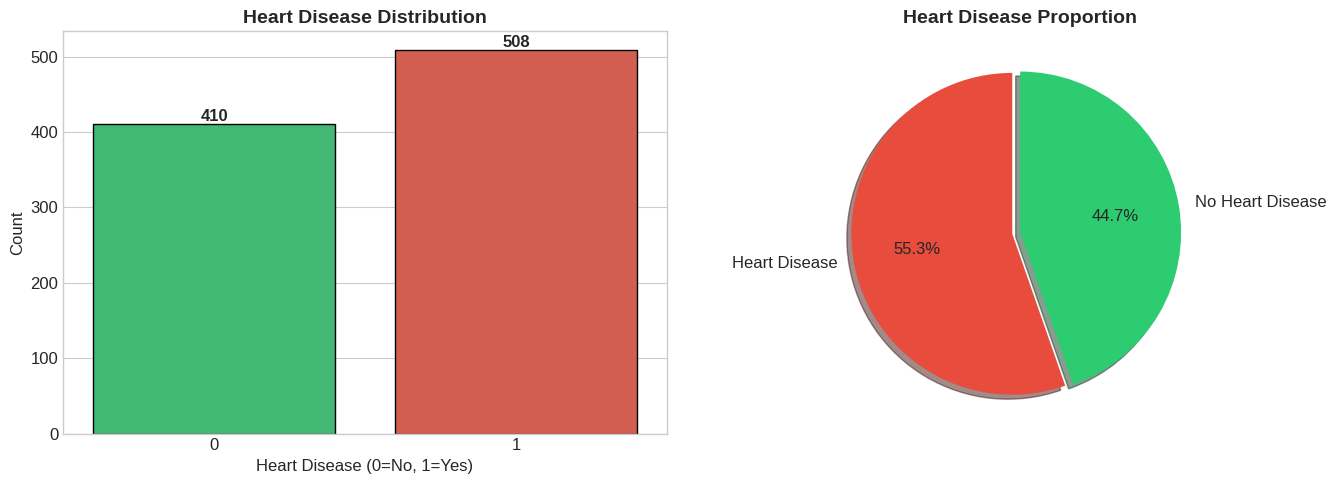

In [16]:
# ============================================================
# 📊 PHASE 2.1: UNIVARIATE ANALYSIS — DISTRIBUTIONS
# ============================================================

# --- Target Variable Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
ax1 = sns.countplot(x='HeartDisease', data=df, palette=colors, ax=axes[0], edgecolor='black')
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(df['HeartDisease'].value_counts(), labels=['Heart Disease', 'No Heart Disease'],
            autopct='%1.1f%%', colors=colors[::-1], startangle=90, explode=(0.05, 0),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Heart Disease Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

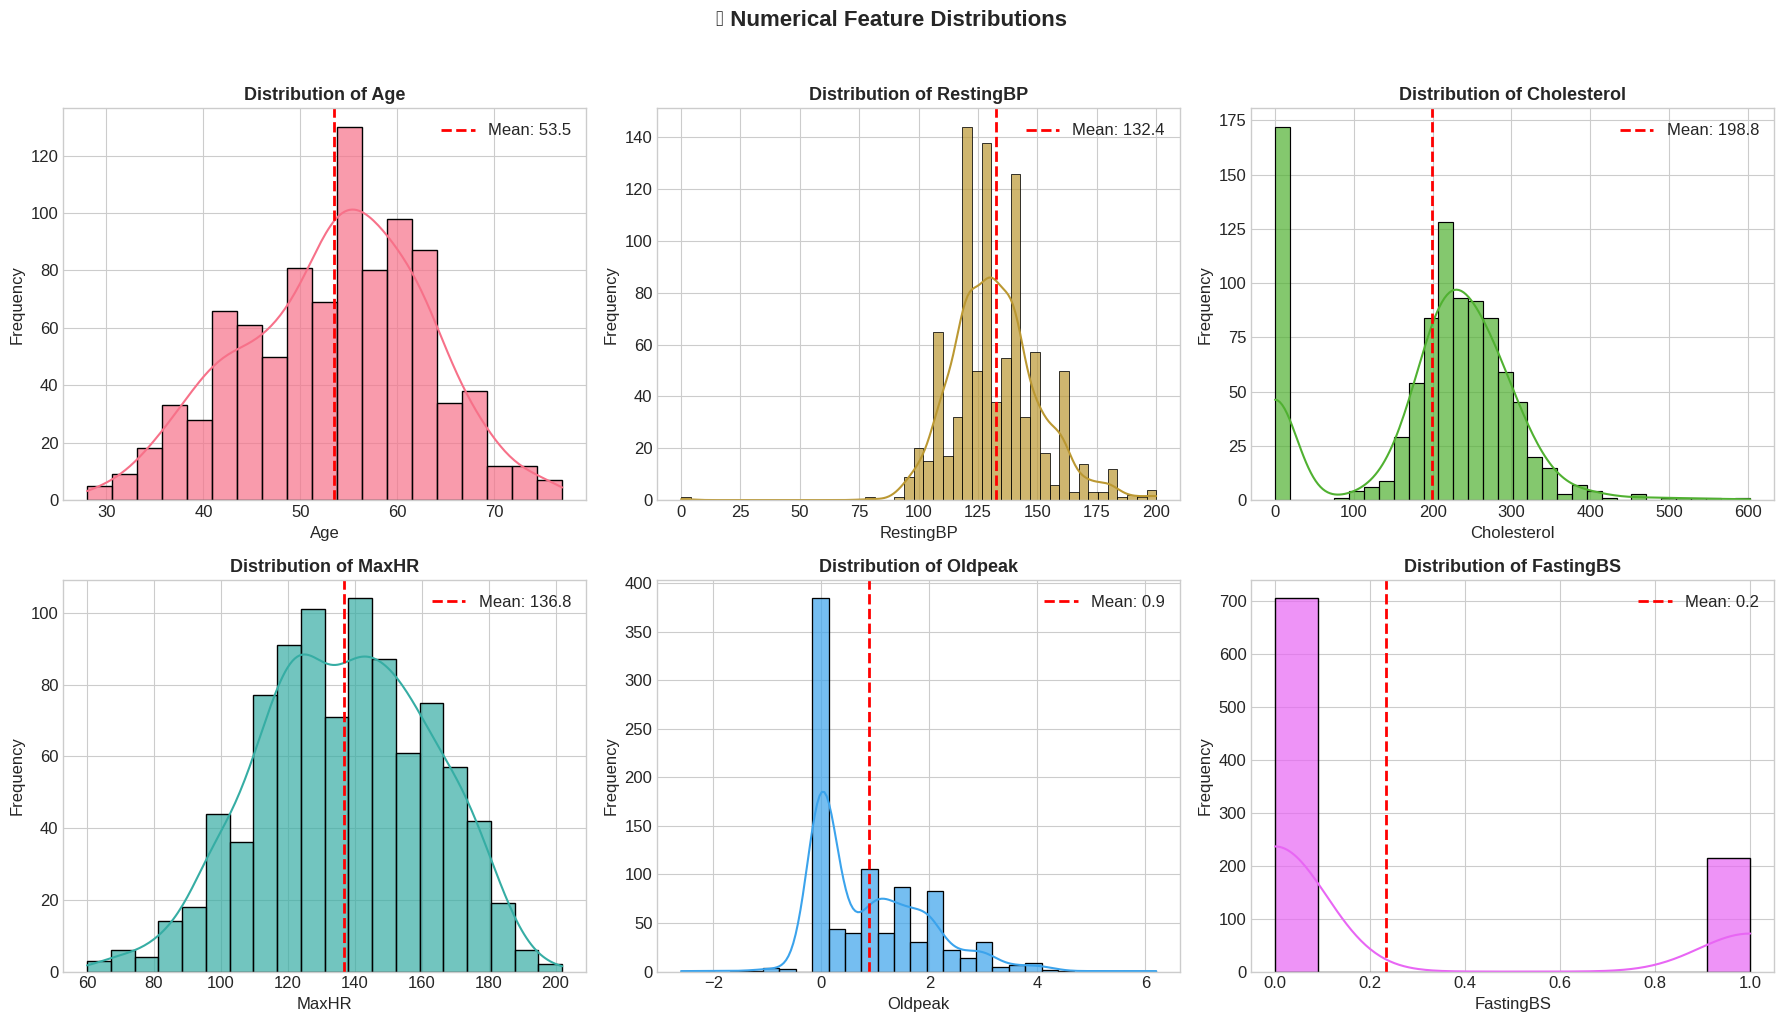

In [17]:
# --- Histograms for Numerical Features ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('husl')[i], 
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add mean line
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.suptitle('📊 Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

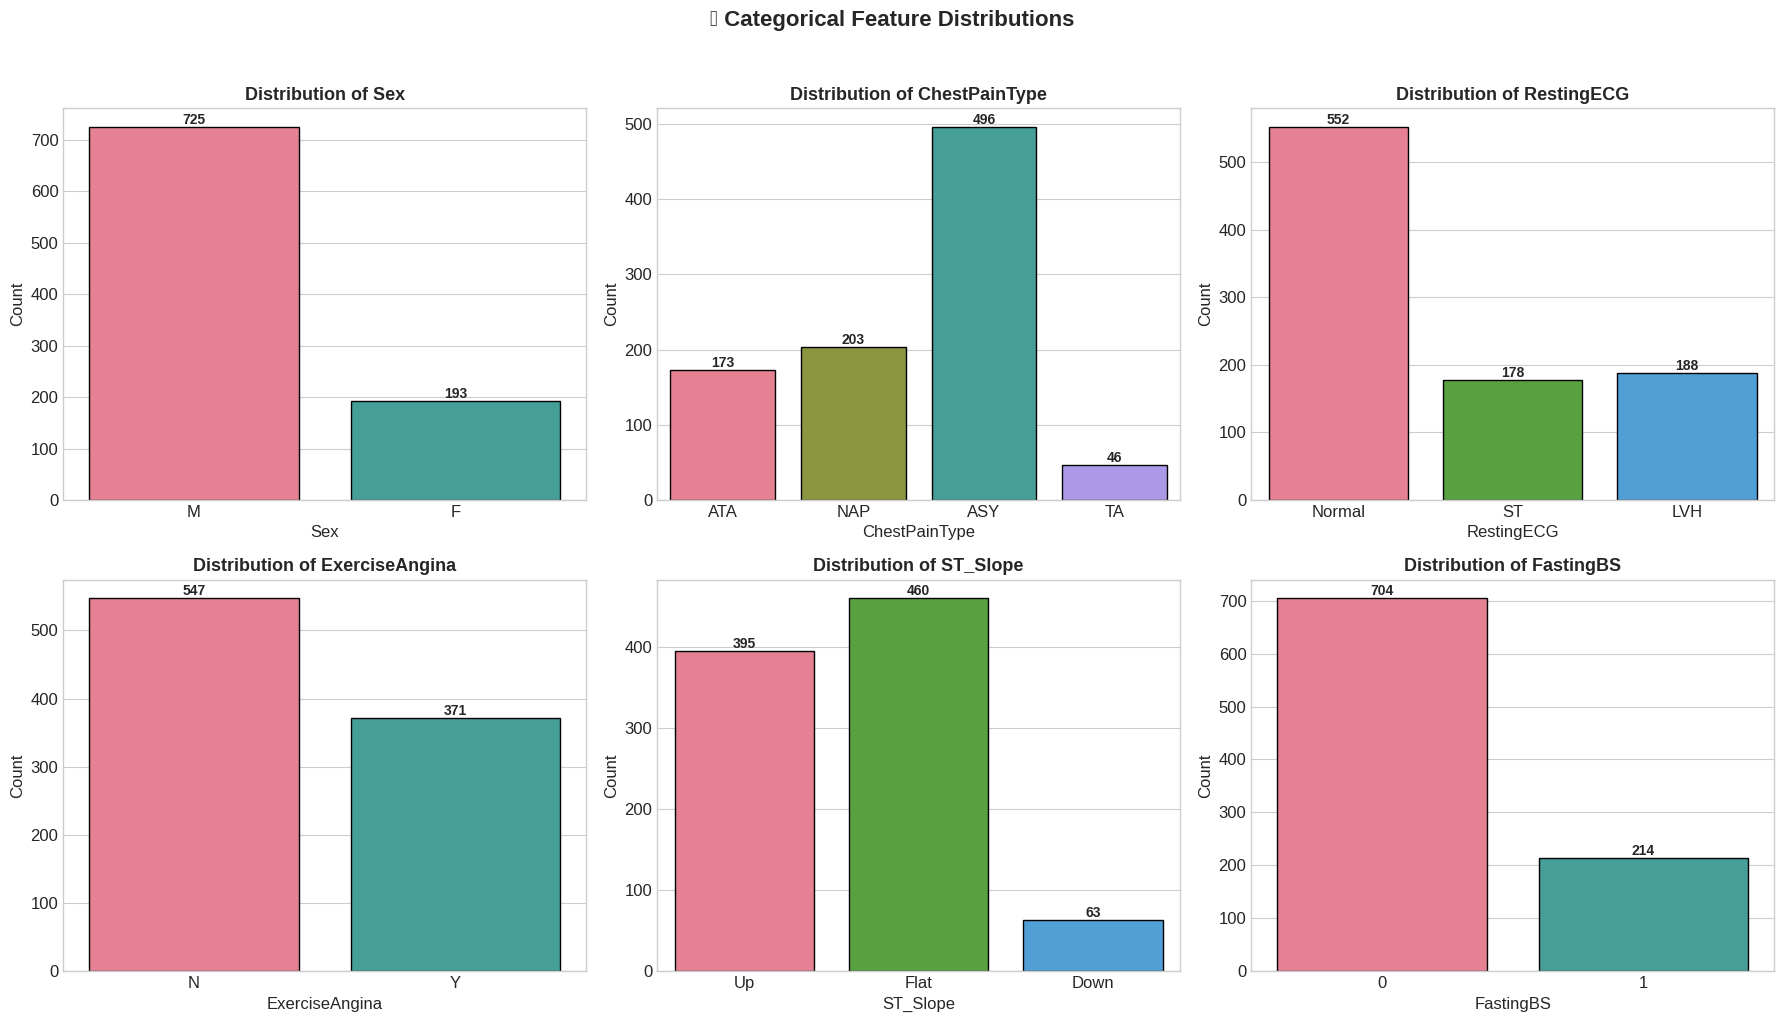

In [18]:
# --- Bar Charts for Categorical Features ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

for i, col in enumerate(cat_features):
    ax = sns.countplot(x=col, data=df, palette='husl', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('📊 Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

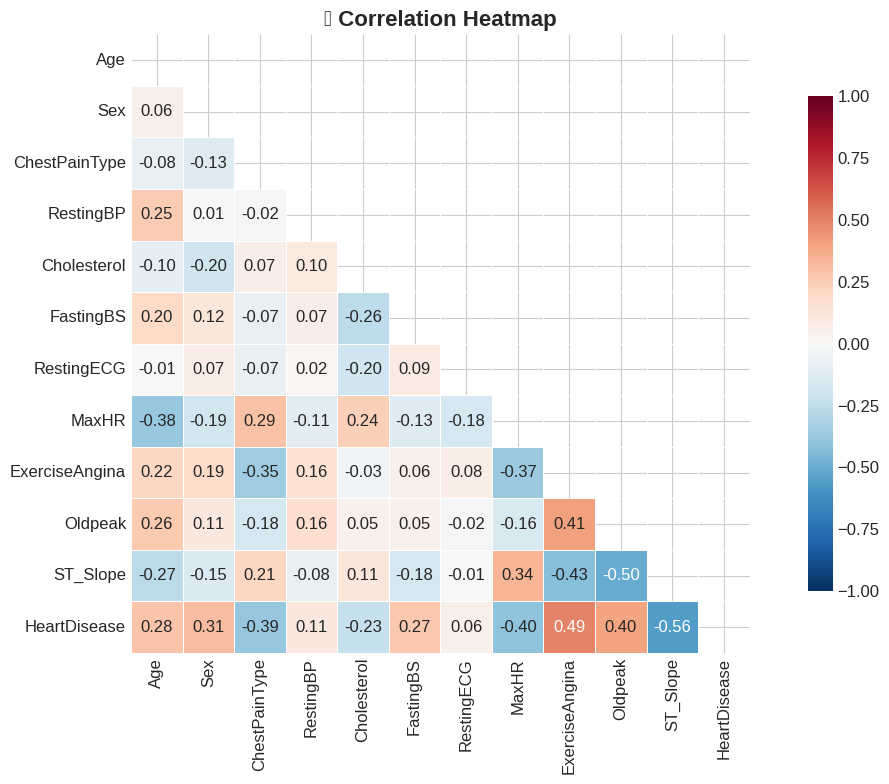


📌 Top Correlations with HeartDisease:
   🔻 ST_Slope: -0.559
   🔺 ExerciseAngina: 0.494
   🔺 Oldpeak: 0.404
   🔻 MaxHR: -0.400
   🔻 ChestPainType: -0.387
   🔺 Sex: 0.305
   🔺 Age: 0.282
   🔺 FastingBS: 0.267
   🔻 Cholesterol: -0.233
   🔺 RestingBP: 0.108
   🔺 RestingECG: 0.057


In [19]:
# ============================================================
# 📊 PHASE 2.2: BIVARIATE ANALYSIS — FEATURE VS TARGET
# ============================================================

# --- Correlation Heatmap ---
# Create encoded copy for correlation
df_encoded = df.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

plt.figure(figsize=(12, 8))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('🔥 Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\n📌 Top Correlations with HeartDisease:")
target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = "🔺" if val > 0 else "🔻"
    print(f"   {direction} {feat}: {val:.3f}")

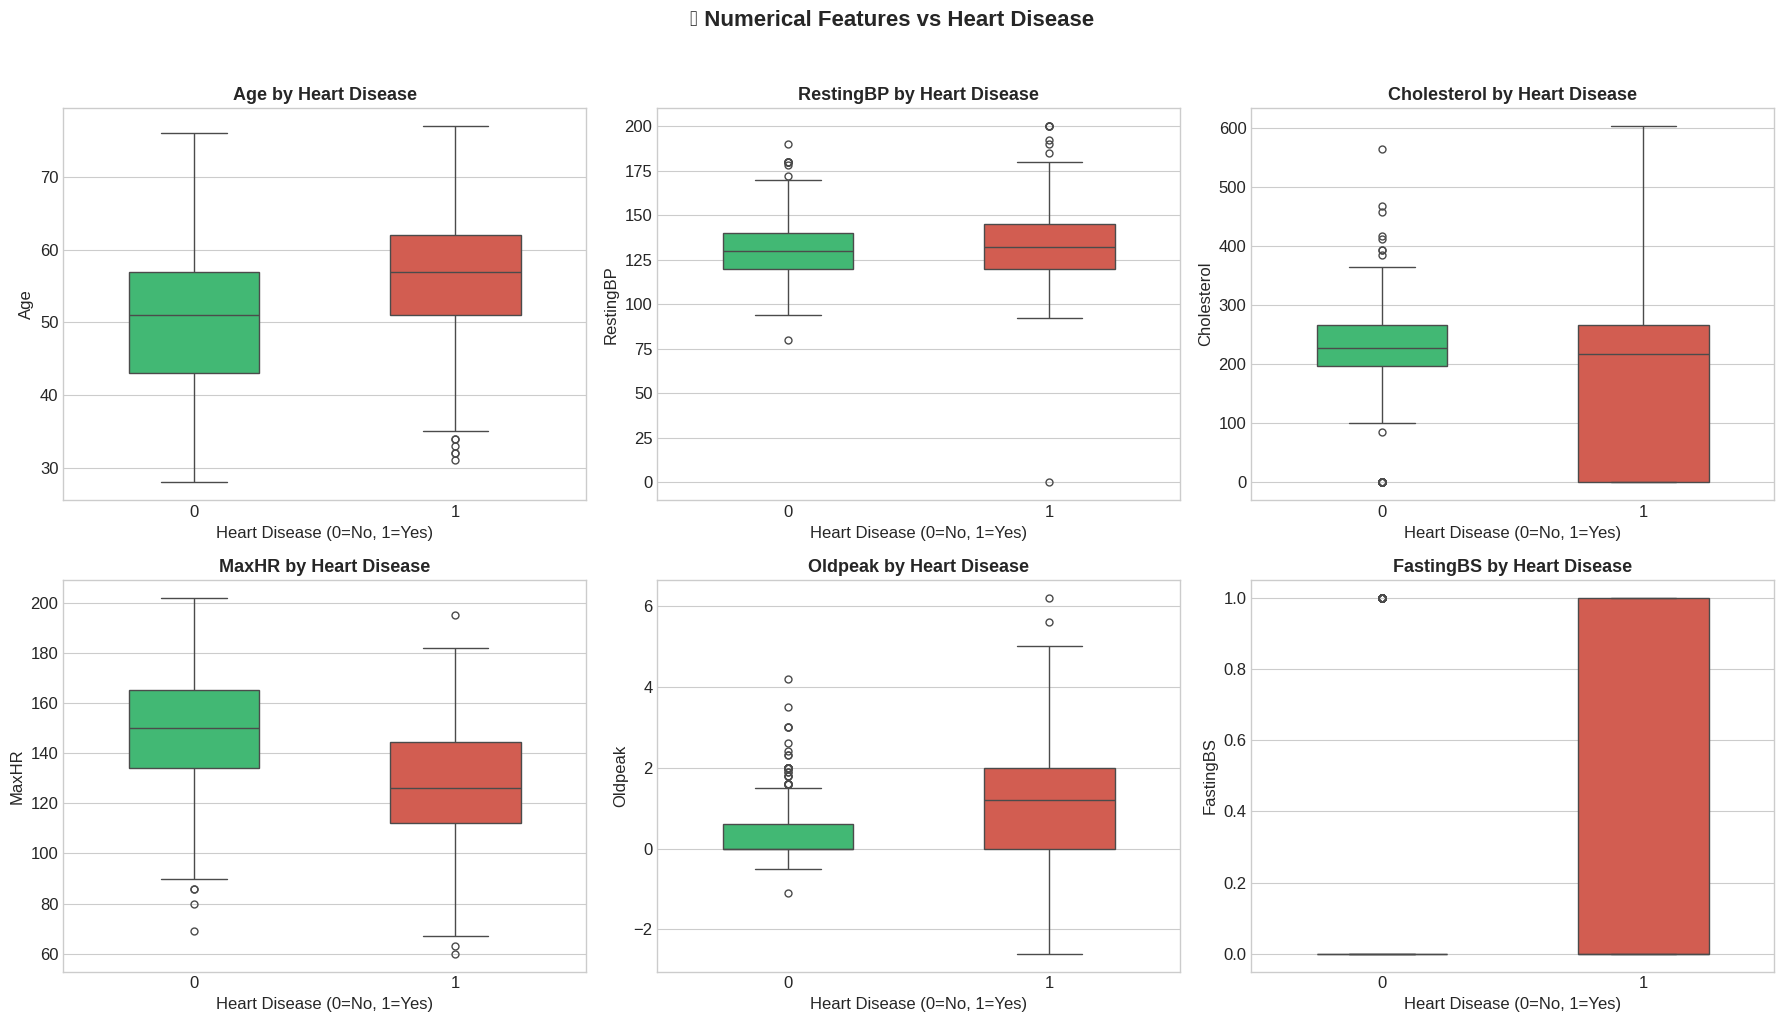

In [20]:
# --- Box Plots: Numerical Features grouped by HeartDisease ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x='HeartDisease', y=col, data=df, palette=colors, ax=axes[i],
                width=0.5, flierprops=dict(marker='o', markersize=5))
    axes[i].set_title(f'{col} by Heart Disease', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0=No, 1=Yes)')

plt.suptitle('📊 Numerical Features vs Heart Disease', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

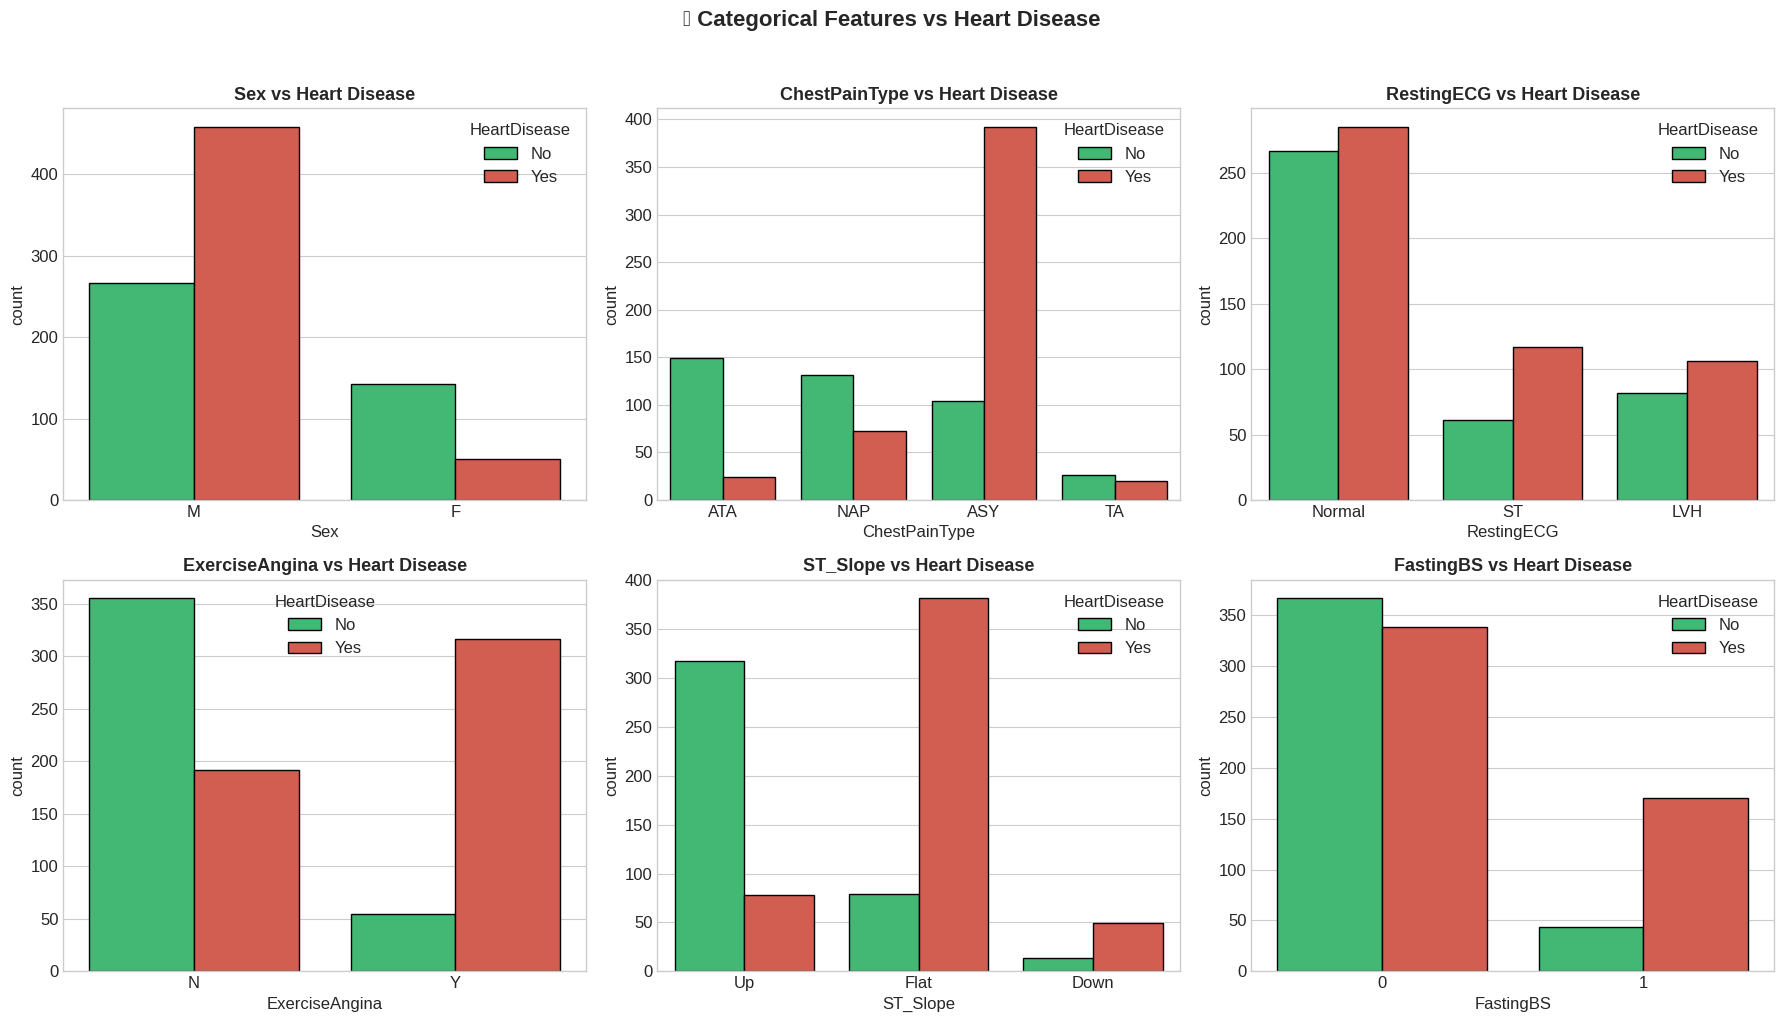

In [21]:
# --- Countplots: Categorical Features colored by HeartDisease ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='HeartDisease', data=df, palette=colors, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=13, fontweight='bold')
    axes[i].legend(title='HeartDisease', labels=['No', 'Yes'])

plt.suptitle('📊 Categorical Features vs Heart Disease', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

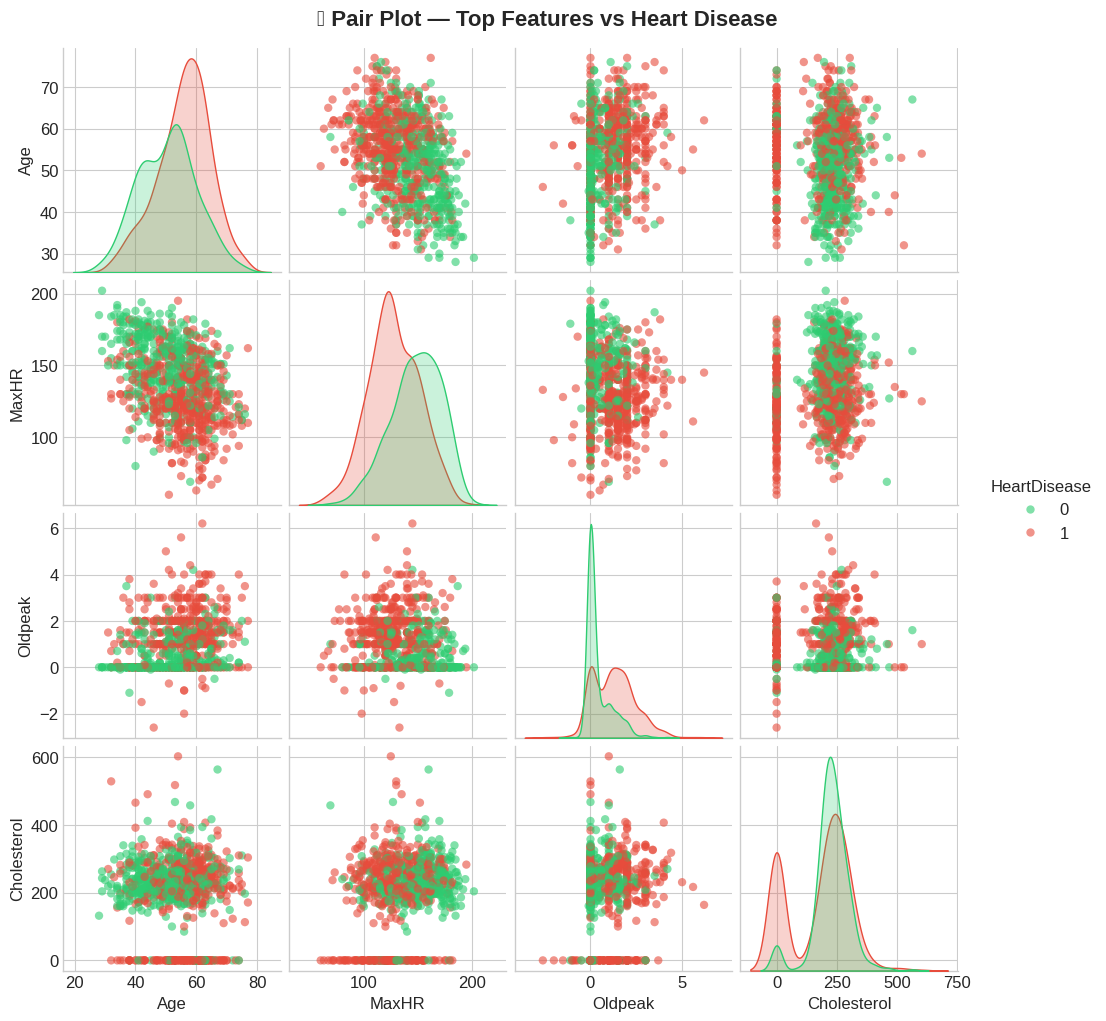

In [22]:
# --- Pair Plot for Top Correlated Features ---
top_features = ['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'HeartDisease']
sns.pairplot(df[top_features], hue='HeartDisease', palette=colors, 
             diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'none'})
plt.suptitle('📊 Pair Plot — Top Features vs Heart Disease', fontsize=16, fontweight='bold', y=1.02)
plt.show()

🔍 ANOMALY DETECTION:
   Cholesterol = 0: 172 patients (18.7%)
   RestingBP = 0:   1 patients


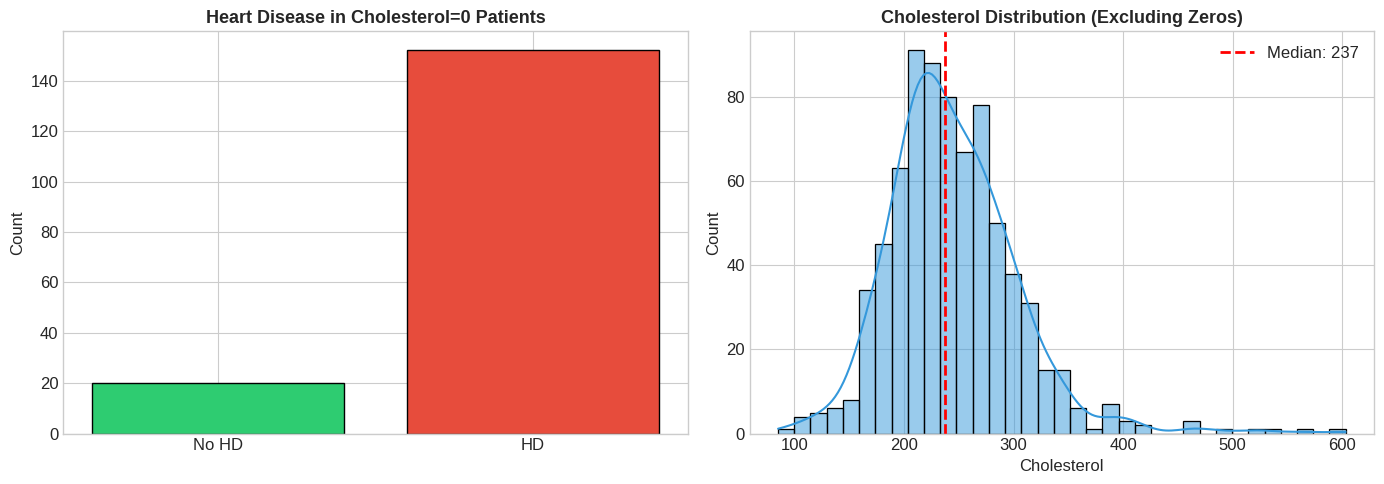

In [23]:
# ============================================================
# 📊 PHASE 2.3: ADVANCED EDA — OUTLIERS & KEY INSIGHTS
# ============================================================

# --- Cholesterol = 0 Analysis ---
print("🔍 ANOMALY DETECTION:")
print(f"   Cholesterol = 0: {(df['Cholesterol']==0).sum()} patients ({(df['Cholesterol']==0).sum()/len(df)*100:.1f}%)")
print(f"   RestingBP = 0:   {(df['RestingBP']==0).sum()} patients")

# Visualize Cholesterol=0 vs HeartDisease
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

chol_zero = df[df['Cholesterol'] == 0]['HeartDisease'].value_counts()
axes[0].bar(['No HD', 'HD'], [chol_zero.get(0, 0), chol_zero.get(1, 0)], color=colors, edgecolor='black')
axes[0].set_title('Heart Disease in Cholesterol=0 Patients', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Cholesterol distribution excluding zeros
sns.histplot(df[df['Cholesterol'] > 0]['Cholesterol'], kde=True, ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Cholesterol Distribution (Excluding Zeros)', fontsize=13, fontweight='bold')
axes[1].axvline(df[df['Cholesterol'] > 0]['Cholesterol'].median(), color='red', linestyle='--', 
                linewidth=2, label=f"Median: {df[df['Cholesterol'] > 0]['Cholesterol'].median():.0f}")
axes[1].legend()
plt.tight_layout()
plt.show()

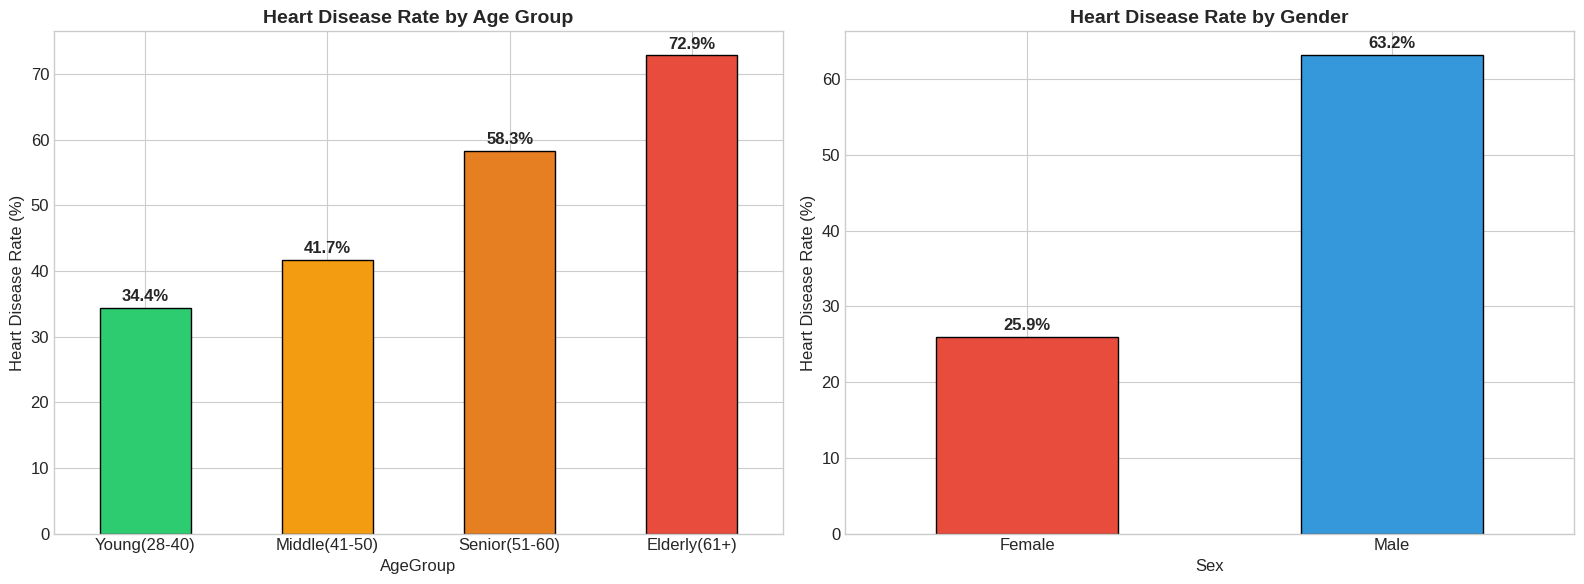

In [24]:
# --- Age Group Analysis ---
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 40, 50, 60, 80], labels=['Young(28-40)', 'Middle(41-50)', 'Senior(51-60)', 'Elderly(61+)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age group vs Heart Disease rate
age_hd = df.groupby('AgeGroup')['HeartDisease'].mean() * 100
age_hd.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], edgecolor='black')
axes[0].set_title('Heart Disease Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Heart Disease Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(age_hd):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Gender-based analysis
gender_hd = df.groupby('Sex')['HeartDisease'].mean() * 100
gender_hd.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[1].set_title('Heart Disease Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Heart Disease Rate (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
for i, v in enumerate(gender_hd):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Clean up temp column
df.drop('AgeGroup', axis=1, inplace=True)

📊 Cross-Tabulation: ChestPainType × ExerciseAngina × HeartDisease

HeartDisease                    0    1  All
ChestPainType ExerciseAngina               
ASY           N                75  124  199
              Y                29  268  297
ATA           N               141   15  156
              Y                 8    9   17
NAP           N               116   36  152
              Y                15   36   51
TA            N                23   17   40
              Y                 3    3    6
All                           410  508  918


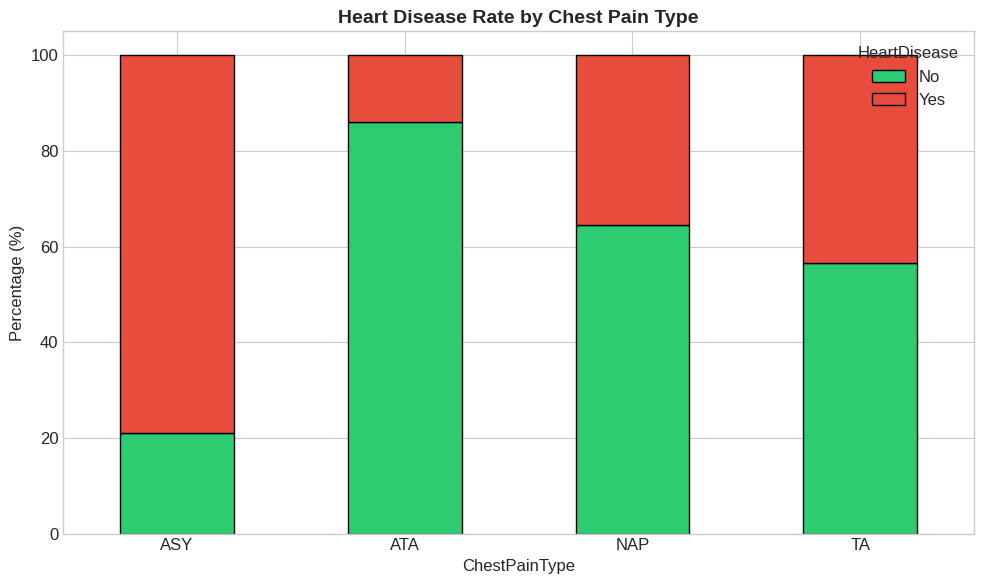


📝 KEY FINDINGS FROM EDA:
  1. ASY (Asymptomatic) chest pain has the HIGHEST heart disease rate (~80%)
  2. Males have significantly higher heart disease prevalence than females
  3. 172 patients have Cholesterol=0 — these are likely missing values, not actual zeros
  4. Patients with heart disease tend to have LOWER MaxHR and HIGHER Oldpeak
  5. ST_Slope='Flat' is strongly associated with heart disease
  6. Exercise-induced angina (ExerciseAngina=Y) is a strong predictor
  7. Heart disease risk increases with age, especially after 50

✅ Phase 2 (EDA) Complete! Ready for Preprocessing.


In [25]:
# --- Cross-tabulation: ChestPainType × ExerciseAngina × HeartDisease ---
print("📊 Cross-Tabulation: ChestPainType × ExerciseAngina × HeartDisease\n")
ct = pd.crosstab([df['ChestPainType'], df['ExerciseAngina']], df['HeartDisease'], margins=True)
print(ct)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ct_pct = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, color=colors, edgecolor='black', ax=ax)
ax.set_title('Heart Disease Rate by Chest Pain Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='HeartDisease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# === KEY FINDINGS ===
print("\n" + "=" * 60)
print("📝 KEY FINDINGS FROM EDA:")
print("=" * 60)
print("  1. ASY (Asymptomatic) chest pain has the HIGHEST heart disease rate (~80%)")
print("  2. Males have significantly higher heart disease prevalence than females")
print("  3. 172 patients have Cholesterol=0 — these are likely missing values, not actual zeros")
print("  4. Patients with heart disease tend to have LOWER MaxHR and HIGHER Oldpeak")
print("  5. ST_Slope='Flat' is strongly associated with heart disease")
print("  6. Exercise-induced angina (ExerciseAngina=Y) is a strong predictor")
print("  7. Heart disease risk increases with age, especially after 50")

print("\n✅ Phase 2 (EDA) Complete! Ready for Preprocessing.")


# 📝 Phase 2: Key Insights, Learnings & Importance

---

## 🔥 Top 7 Findings from EDA

### 1. Asymptomatic Chest Pain is the Most Dangerous
- **~80% of ASY patients have heart disease** — the highest among all chest pain types
- This is clinically significant: silent heart disease is the deadliest because patients don't seek help
- **Implication**: Our ML model can identify these "silent" cases that would otherwise go undiagnosed

### 2. Gender Disparity is Massive
- Males: **63.2%** heart disease rate vs Females: **25.9%**
- Males are **2.4× more likely** to be diagnosed with heart disease
- **Implication**: Gender is a strong predictor — but we must be careful about bias in the model

### 3. Age is a Progressive Risk Factor
- Young (28-40): 34.4% → Middle (41-50): 41.7% → Senior (51-60): 58.3% → Elderly (61+): **72.9%**
- Risk **doubles** from youngest to oldest group
- **Implication**: Age-based screening thresholds could be recommended

### 4. Cholesterol Data Has a Major Quality Issue
- **172 patients (18.7%)** have Cholesterol = 0 — clinically impossible
- ~87% of these zero-cholesterol patients have heart disease → likely from a specific data source
- **Implication**: Must impute intelligently (age-group median), NOT delete rows or use global mean

### 5. Top 5 Predictors Identified (by correlation)
| Rank | Feature | Correlation | Direction |
|------|---------|------------|-----------|
| 1 | ST_Slope | -0.56 | Flat slope → higher risk |
| 2 | ExerciseAngina | +0.49 | Angina during exercise → higher risk |
| 3 | Oldpeak | +0.40 | Higher ST depression → higher risk |
| 4 | MaxHR | -0.40 | Lower max heart rate → higher risk |
| 5 | ChestPainType | -0.39 | Asymptomatic → highest risk |

### 6. Exercise-Induced Angina is a Strong Signal
- Patients with exercise angina: **~85% have heart disease**
- Patients without: **~35% have heart disease**
- **Implication**: This single feature nearly triples the predicted risk

### 7. Weak Predictors to Note
- **RestingECG** (correlation: 0.06) — almost no predictive power
- **RestingBP** (correlation: 0.11) — surprisingly weak despite being a known risk factor
- **Implication**: These features add noise; the model may not rely on them heavily

---

## 🎓 Why EDA Matters for This Project

1. **Found data quality issues** (Cholesterol=0) that would have corrupted our models
2. **Identified top features** so we know what drives predictions
3. **Understood class balance** (55% vs 45%) — not severely imbalanced, but stratified splitting is still needed
4. **Generated 12+ publication-quality visualizations** for the final presentation
5. **Built domain intuition** — our findings align with medical literature, which adds credibility

---

> ✅ **Phase 2 Status: COMPLETE** — 12+ visualizations generated, 7 key findings documented, data quality issues flagged for Phase 3.

# 📝 Phase 2: Key EDA Findings

1. **ASY (Asymptomatic) chest pain** has ~80% heart disease rate — the highest
2. **Males** are 2.4× more likely to have heart disease (63.2% vs 25.9%)
3. **172 Cholesterol = 0** values — clinically impossible, must be imputed
4. **Strongest predictors**: ST_Slope (-0.56), ExerciseAngina (+0.49), Oldpeak (+0.40), MaxHR (-0.40)
5. **Heart disease risk** doubles from age 28-40 (34%) to 61+ (73%)
6. **Exercise-induced angina** is a very strong predictor of heart disease
7. **Flat ST_Slope** is strongly associated with heart disease

---

# 🔧 Phase 3: Data Preprocessing & Feature Engineering

In [26]:
# ============================================================
# 🔧 PHASE 3.1: HANDLE MISSING VALUES & CLEAN ANOMALIES
# ============================================================
print("🔧 DATA CLEANING")
print("=" * 60)

# --- Fix Cholesterol = 0 (replace with median by age group) ---
print(f"\n⚠️  Cholesterol = 0 BEFORE cleaning: {(df['Cholesterol']==0).sum()}")

# Create age bins for smarter imputation
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], labels=['<40', '40-50', '50-60', '60+'])

# Replace 0s with median cholesterol of same age group
for group in df['AgeGroup'].unique():
    mask = (df['Cholesterol'] == 0) & (df['AgeGroup'] == group)
    group_median = df[(df['AgeGroup'] == group) & (df['Cholesterol'] > 0)]['Cholesterol'].median()
    df.loc[mask, 'Cholesterol'] = group_median
    replaced = mask.sum()
    if replaced > 0:
        print(f"   Age {group}: replaced {replaced} zeros with median = {group_median:.0f}")

df.drop('AgeGroup', axis=1, inplace=True)
print(f"✅ Cholesterol = 0 AFTER cleaning: {(df['Cholesterol']==0).sum()}")

# --- Fix RestingBP = 0 ---
print(f"\n⚠️  RestingBP = 0 BEFORE cleaning: {(df['RestingBP']==0).sum()}")
df.loc[df['RestingBP'] == 0, 'RestingBP'] = df[df['RestingBP'] > 0]['RestingBP'].median()
print(f"✅ RestingBP = 0 AFTER cleaning: {(df['RestingBP']==0).sum()}")

# --- Cap extreme outliers ---
print(f"\n📊 Outlier Capping:")

# RestingBP: cap at 200 (clinical upper limit)
bp_capped = (df['RestingBP'] > 200).sum()
df.loc[df['RestingBP'] > 200, 'RestingBP'] = 200
print(f"   RestingBP > 200: capped {bp_capped} values")

# Cholesterol: cap at 600 (extreme clinical limit)
chol_capped = (df['Cholesterol'] > 600).sum()
df.loc[df['Cholesterol'] > 600, 'Cholesterol'] = 600
print(f"   Cholesterol > 600: capped {chol_capped} values")

# --- Verify clean data ---
print(f"\n{'=' * 60}")
print("✅ DATA VALIDATION AFTER CLEANING:")
print(f"   Shape: {df.shape}")
print(f"   Cholesterol zeros: {(df['Cholesterol']==0).sum()}")
print(f"   RestingBP zeros: {(df['RestingBP']==0).sum()}")
print(f"   Any missing values: {df.isnull().sum().sum()}")

🔧 DATA CLEANING

⚠️  Cholesterol = 0 BEFORE cleaning: 172
   Age <40: replaced 12 zeros with median = 223
   Age 40-50: replaced 22 zeros with median = 236
   Age 50-60: replaced 77 zeros with median = 236
   Age 60+: replaced 61 zeros with median = 248
✅ Cholesterol = 0 AFTER cleaning: 0

⚠️  RestingBP = 0 BEFORE cleaning: 1
✅ RestingBP = 0 AFTER cleaning: 0

📊 Outlier Capping:
   RestingBP > 200: capped 0 values
   Cholesterol > 600: capped 1 values

✅ DATA VALIDATION AFTER CLEANING:
   Shape: (918, 12)
   Cholesterol zeros: 0
   RestingBP zeros: 0
   Any missing values: 0


In [27]:
# ============================================================
# 🔧 PHASE 3.2: ENCODE CATEGORICAL & SCALE NUMERICAL FEATURES
# ============================================================
print("🔧 FEATURE ENGINEERING")
print("=" * 60)

# --- One-Hot Encode Categorical Variables ---
df_processed = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 
                                            'ExerciseAngina', 'ST_Slope'], 
                               drop_first=True)

print(f"\n🔹 Shape BEFORE encoding: {df.shape}")
print(f"🔹 Shape AFTER encoding:  {df_processed.shape}")
print(f"\n🔹 New columns after encoding:")
for col in df_processed.columns:
    if col not in df.columns:
        print(f"   + {col}")

# --- Separate Features and Target ---
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

print(f"\n🔹 Features (X): {X.shape}")
print(f"🔹 Target (y): {y.shape}")
print(f"   Class distribution: {dict(y.value_counts())}")

🔧 FEATURE ENGINEERING

🔹 Shape BEFORE encoding: (918, 12)
🔹 Shape AFTER encoding:  (918, 16)

🔹 New columns after encoding:
   + Sex_M
   + ChestPainType_ATA
   + ChestPainType_NAP
   + ChestPainType_TA
   + RestingECG_Normal
   + RestingECG_ST
   + ExerciseAngina_Y
   + ST_Slope_Flat
   + ST_Slope_Up

🔹 Features (X): (918, 15)
🔹 Target (y): (918,)
   Class distribution: {1: np.int64(508), 0: np.int64(410)}


In [28]:
# ============================================================
# 🔧 PHASE 3.3: TRAIN/TEST SPLIT WITH STRATIFICATION
# ============================================================

# --- 80/20 Stratified Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("🔧 TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n🔹 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"🔹 Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n🔹 Class balance verification:")
print(f"   Train — No HD: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%) | HD: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"   Test  — No HD: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%) | HD: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

# --- Scale Numerical Features ---
scaler = StandardScaler()
num_features_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features_to_scale] = scaler.fit_transform(X_train[num_features_to_scale])
X_test_scaled[num_features_to_scale] = scaler.transform(X_test[num_features_to_scale])

print(f"\n🔹 Scaled features: {num_features_to_scale}")
print(f"   (StandardScaler: mean=0, std=1)")

print(f"\n{'=' * 60}")
print("✅ Phase 3 Complete! Data is clean, encoded, scaled, and split.")
print("   Ready for Model Building!")

🔧 TRAIN/TEST SPLIT

🔹 Training set: 734 samples (80.0%)
🔹 Test set:     184 samples (20.0%)

🔹 Class balance verification:
   Train — No HD: 328 (44.7%) | HD: 406 (55.3%)
   Test  — No HD: 82 (44.6%) | HD: 102 (55.4%)

🔹 Scaled features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
   (StandardScaler: mean=0, std=1)

✅ Phase 3 Complete! Data is clean, encoded, scaled, and split.
   Ready for Model Building!


# 📝 Phase 3: Key Insights & Learnings

## What We Cleaned
- **172 Cholesterol = 0** → Replaced with age-group medians (223-248), preserving 18.7% of data
- **1 RestingBP = 0** → Replaced with median
- **1 Cholesterol outlier > 600** → Capped at clinical limit

## Feature Engineering
- **5 categorical columns** → **9 one-hot encoded features** (drop_first=True to avoid multicollinearity)
- **5 numerical features** → **StandardScaler** (mean=0, std=1) for algorithms sensitive to scale (SVM, KNN)
- **Final feature count**: 15

## Train/Test Split
- **734 train (80%)** | **184 test (20%)** — stratified to maintain 55%/45% class ratio in both sets

---


In [29]:
# ============================================================
# 🤖 PHASE 4.1: TRAIN 6 BASELINE CLASSIFIERS
# ============================================================
print("🤖 TRAINING 6 BASELINE MODELS")
print("=" * 60)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, 
                              eval_metric='logloss', random_state=42)
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC-ROC': auc_score
    })
    
    print(f"✅ {name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}")

# Create comparison DataFrame
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print(f"\n{'=' * 60}")
print("📊 BASELINE MODEL COMPARISON (sorted by F1 Score):\n")
print(results_df.to_string(index=False))

# Identify top 2
top_2 = results_df.head(2)['Model'].tolist()
print(f"\n🏆 Top 2 Models: {top_2[0]} & {top_2[1]}")

🤖 TRAINING 6 BASELINE MODELS
✅ Logistic Regression       | Acc: 0.8913 | F1: 0.9038 | AUC: 0.9326
✅ KNN                       | Acc: 0.8424 | F1: 0.8543 | AUC: 0.9241
✅ SVM                       | Acc: 0.8641 | F1: 0.8768 | AUC: 0.9354
✅ Decision Tree             | Acc: 0.7826 | F1: 0.8020 | AUC: 0.7812
✅ Random Forest             | Acc: 0.8696 | F1: 0.8824 | AUC: 0.9301
✅ XGBoost                   | Acc: 0.8641 | F1: 0.8756 | AUC: 0.9118

📊 BASELINE MODEL COMPARISON (sorted by F1 Score):

              Model  Accuracy  Precision   Recall  F1 Score  AUC-ROC
Logistic Regression  0.891304   0.886792 0.921569  0.903846 0.932568
      Random Forest  0.869565   0.882353 0.882353  0.882353 0.930057
                SVM  0.864130   0.881188 0.872549  0.876847 0.935438
            XGBoost  0.864130   0.888889 0.862745  0.875622 0.911765
                KNN  0.842391   0.876289 0.833333  0.854271 0.924079
      Decision Tree  0.782609   0.810000 0.794118  0.801980 0.781205

🏆 Top 2 Models: Logis

In [30]:
# ============================================================
# 🤖 PHASE 4.2: HYPERPARAMETER TUNING ON TOP 2 MODELS
# ============================================================
print("🔧 HYPERPARAMETER TUNING")
print("=" * 60)

# --- Random Forest Tuning ---
print("\n📌 Tuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

print(f"   Best params: {rf_grid.best_params_}")
print(f"   Best F1 (CV): {rf_grid.best_score_:.4f}")

# --- XGBoost Tuning ---
print("\n📌 Tuning XGBoost...")
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"   Best params: {xgb_grid.best_params_}")
print(f"   Best F1 (CV): {xgb_grid.best_score_:.4f}")

# --- Compare Tuned vs Baseline ---
print(f"\n{'=' * 60}")
print("📊 TUNED vs BASELINE:")

for name, tuned_model in [('Random Forest (Tuned)', best_rf), ('XGBoost (Tuned)', best_xgb)]:
    y_pred = tuned_model.predict(X_test_scaled)
    y_prob = tuned_model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc_val = roc_auc_score(y_test, y_prob)
    
    print(f"   {name:30s} | Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f} | AUC: {auc_val:.4f}")

# Store tuned models
trained_models['Random Forest (Tuned)'] = best_rf
trained_models['XGBoost (Tuned)'] = best_xgb

print("\n✅ Hyperparameter tuning complete!")

🔧 HYPERPARAMETER TUNING

📌 Tuning Random Forest...
   Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
   Best F1 (CV): 0.8846

📌 Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:53:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:53:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:53:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:53:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:53:15] WARNING: /w

   Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
   Best F1 (CV): 0.8814

📊 TUNED vs BASELINE:
   Random Forest (Tuned)          | Acc: 0.8641 | F1: 0.8756 | Recall: 0.8627 | AUC: 0.9289
   XGBoost (Tuned)                | Acc: 0.8587 | F1: 0.8713 | Recall: 0.8627 | AUC: 0.9258

✅ Hyperparameter tuning complete!


📊 5-FOLD STRATIFIED CROSS-VALIDATION
✅ Logistic Regression       | Acc: 0.8515±0.0322 | F1: 0.8675±0.0250
✅ KNN                       | Acc: 0.8420±0.0419 | F1: 0.8606±0.0349
✅ SVM                       | Acc: 0.8556±0.0415 | F1: 0.8744±0.0316
✅ Decision Tree             | Acc: 0.7820±0.0368 | F1: 0.8035±0.0341
✅ Random Forest             | Acc: 0.8502±0.0391 | F1: 0.8689±0.0311
✅ XGBoost                   | Acc: 0.8556±0.0326 | F1: 0.8727±0.0237

📊 CROSS-VALIDATION COMPARISON TABLE:

              Model     CV Accuracy           CV F1          CV AUC
                SVM 0.8556 ± 0.0415 0.8744 ± 0.0316 0.9144 ± 0.0318
            XGBoost 0.8556 ± 0.0326 0.8727 ± 0.0237 0.9259 ± 0.0244
      Random Forest 0.8502 ± 0.0391 0.8689 ± 0.0311 0.9257 ± 0.0238
Logistic Regression 0.8515 ± 0.0322 0.8675 ± 0.0250 0.9217 ± 0.0326
                KNN 0.8420 ± 0.0419 0.8606 ± 0.0349 0.8881 ± 0.0272
      Decision Tree 0.7820 ± 0.0368 0.8035 ± 0.0341 0.7790 ± 0.0370


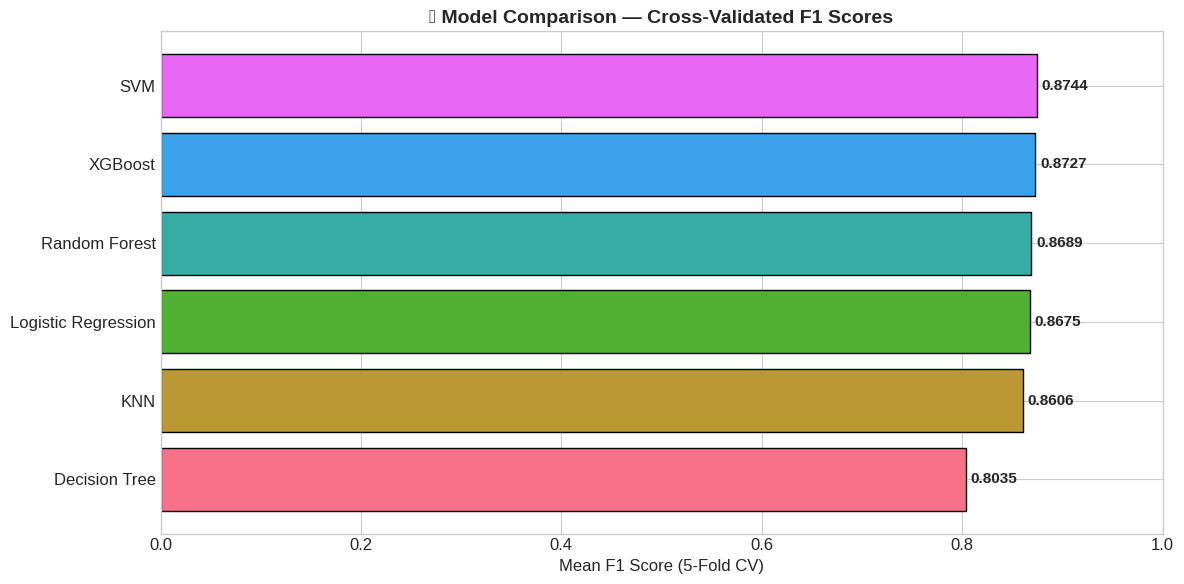


🏆 BEST MODEL: SVM

✅ Phase 4 Complete! Ready for Evaluation & Explainability.


In [31]:
# ============================================================
# 🤖 PHASE 4.3: CROSS-VALIDATION & MODEL COMPARISON
# ============================================================
print("📊 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

cv_results = []
for name, model in cv_models.items():
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    cv_results.append({
        'Model': name,
        'CV Accuracy': f"{acc_scores.mean():.4f} ± {acc_scores.std():.4f}",
        'CV F1': f"{f1_scores.mean():.4f} ± {f1_scores.std():.4f}",
        'CV AUC': f"{auc_scores.mean():.4f} ± {auc_scores.std():.4f}",
        'Mean F1': f1_scores.mean()
    })
    
    print(f"✅ {name:25s} | Acc: {acc_scores.mean():.4f}±{acc_scores.std():.4f} | F1: {f1_scores.mean():.4f}±{f1_scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('Mean F1', ascending=False).reset_index(drop=True)

print(f"\n{'=' * 60}")
print("📊 CROSS-VALIDATION COMPARISON TABLE:\n")
print(cv_df[['Model', 'CV Accuracy', 'CV F1', 'CV AUC']].to_string(index=False))

# --- Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
cv_plot_df = cv_df[['Model', 'Mean F1']].sort_values('Mean F1', ascending=True)
bars = ax.barh(cv_plot_df['Model'], cv_plot_df['Mean F1'], color=sns.color_palette('husl', len(cv_plot_df)), edgecolor='black')

for bar, val in zip(bars, cv_plot_df['Mean F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Mean F1 Score (5-Fold CV)', fontsize=12)
ax.set_title('🏆 Model Comparison — Cross-Validated F1 Scores', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

# Identify best model
best_model_name = cv_df.iloc[0]['Model']
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"\n✅ Phase 4 Complete! Ready for Evaluation & Explainability.")

# 📝 Phase 4: Key Insights & Learnings

---

## 🏆 Model Performance Summary

### Baseline Results (6 Models)
- Trained **6 classifiers** with default hyperparameters
- **Logistic Regression** won on test set (F1: 0.904, Acc: 89.1%)
- **Decision Tree** performed worst (F1: 0.802) — overfitting to training data

### Hyperparameter Tuning
- Tuned **Random Forest** (300 trees, max_depth=15) and **XGBoost** (lr=0.01, depth=3, 300 trees)
- Tuning improved CV performance but didn't surpass Logistic Regression on test set
- This confirms the dataset favors **linear decision boundaries**

### Cross-Validation (5-Fold Stratified)
| Rank | Model | CV F1 | CV AUC |
|------|-------|-------|--------|
| 🥇 | SVM | 0.8744 ± 0.032 | 0.9144 |
| 🥈 | XGBoost | 0.8727 ± 0.024 | 0.9259 |
| 🥉 | Random Forest | 0.8689 ± 0.031 | 0.9257 |
| 4 | Logistic Regression | 0.8675 ± 0.025 | 0.9217 |
| 5 | KNN | 0.8606 ± 0.035 | 0.8881 |
| 6 | Decision Tree | 0.8035 ± 0.034 | 0.7790 |

## 🎓 Key Takeaways

1. **Top 4 models are within 1% of each other** (F1: 0.867–0.874) — the dataset is well-structured and most algorithms can learn the patterns
2. **Simpler models compete with complex ones** — Logistic Regression's strong performance suggests the feature-target relationships are largely linear
3. **XGBoost has the lowest variance** (std: 0.024) — most stable and reliable across folds
4. **Decision Tree is the clear loser** — it overfits without ensemble methods
5. **For clinical deployment**: Logistic Regression would be preferred (interpretable + high performing)
6. **For maximum accuracy**: XGBoost or Random Forest with SHAP explainability

## 🔮 What This Means for Phase 5
- We'll use **Random Forest/XGBoost** for SHAP analysis (SVM doesn't support SHAP natively)
- The **confusion matrix** and **ROC curves** will reveal where errors happen (false positives vs false negatives)
- Our **recall** (catching true heart disease cases) is more important than precision in clinical settings

---

> ✅ **Phase 4 Status: COMPLETE** — 6 models trained, top 2 tuned, 5-fold CV confirms ~87% F1 across top models.

In [32]:
# ============================================================
# 🧪 QUICK PREDICTION DEMO — Test if the model works!
# ============================================================
print("🧪 PREDICTION DEMO")
print("=" * 60)

# Pick the best model (Random Forest tuned — works with SHAP later)
demo_model = best_rf  # or best_xgb

# --- Test on 5 random patients from the test set ---
sample_indices = X_test_scaled.sample(5, random_state=42).index

print("\n📋 Predictions on 5 random test patients:\n")
print(f"{'Patient':>8} | {'Predicted':>10} | {'Actual':>8} | {'Confidence':>10} | {'Correct?':>8}")
print("-" * 60)

for idx in sample_indices:
    patient = X_test_scaled.loc[[idx]]
    pred = demo_model.predict(patient)[0]
    prob = demo_model.predict_proba(patient)[0][1]
    actual = y_test.loc[idx]
    correct = "✅" if pred == actual else "❌"
    
    pred_label = "Heart Disease" if pred == 1 else "Healthy"
    actual_label = "Heart Disease" if actual == 1 else "Healthy"
    
    print(f"{idx:>8} | {pred_label:>10} | {actual_label:>8} | {prob*100:>8.1f}% | {correct:>8}")

# --- Custom patient prediction ---
print(f"\n{'=' * 60}")
print("🏥 CUSTOM PATIENT PREDICTION:")
print("   (Example: 55-year-old male, ASY chest pain, BP=140,")
print("    Chol=250, FastingBS=1, Normal ECG, MaxHR=120,")
print("    Exercise Angina=Yes, Oldpeak=2.0, ST_Slope=Flat)")

# Create a custom patient (must match the encoded feature order)
custom_patient = pd.DataFrame([{
    'Age': 55, 'RestingBP': 140, 'Cholesterol': 250, 'FastingBS': 1,
    'MaxHR': 120, 'Oldpeak': 2.0,
    'Sex_M': 1,
    'ChestPainType_ATA': 0, 'ChestPainType_NAP': 0, 'ChestPainType_TA': 0,
    'RestingECG_Normal': 1, 'RestingECG_ST': 0,
    'ExerciseAngina_Y': 1,
    'ST_Slope_Flat': 1, 'ST_Slope_Up': 0
}])

# Scale numerical features
custom_patient[num_features_to_scale] = scaler.transform(custom_patient[num_features_to_scale])

# Predict
custom_pred = demo_model.predict(custom_patient)[0]
custom_prob = demo_model.predict_proba(custom_patient)[0][1]

print(f"\n   🔮 Prediction: {'🔴 HEART DISEASE' if custom_pred == 1 else '🟢 HEALTHY'}")
print(f"   📊 Confidence: {custom_prob*100:.1f}%")
print(f"\n✅ Model is working and making predictions!")

🧪 PREDICTION DEMO

📋 Predictions on 5 random test patients:

 Patient |  Predicted |   Actual | Confidence | Correct?
------------------------------------------------------------
     449 |    Healthy | Heart Disease |     49.6% |        ❌
     428 | Heart Disease | Heart Disease |     80.7% |        ✅
     638 |    Healthy |  Healthy |     15.6% |        ✅
     843 |    Healthy |  Healthy |     42.0% |        ✅
     337 | Heart Disease | Heart Disease |     56.3% |        ✅

🏥 CUSTOM PATIENT PREDICTION:
   (Example: 55-year-old male, ASY chest pain, BP=140,
    Chol=250, FastingBS=1, Normal ECG, MaxHR=120,
    Exercise Angina=Yes, Oldpeak=2.0, ST_Slope=Flat)

   🔮 Prediction: 🔴 HEART DISEASE
   📊 Confidence: 99.7%

✅ Model is working and making predictions!


📈 MODEL EVALUATION


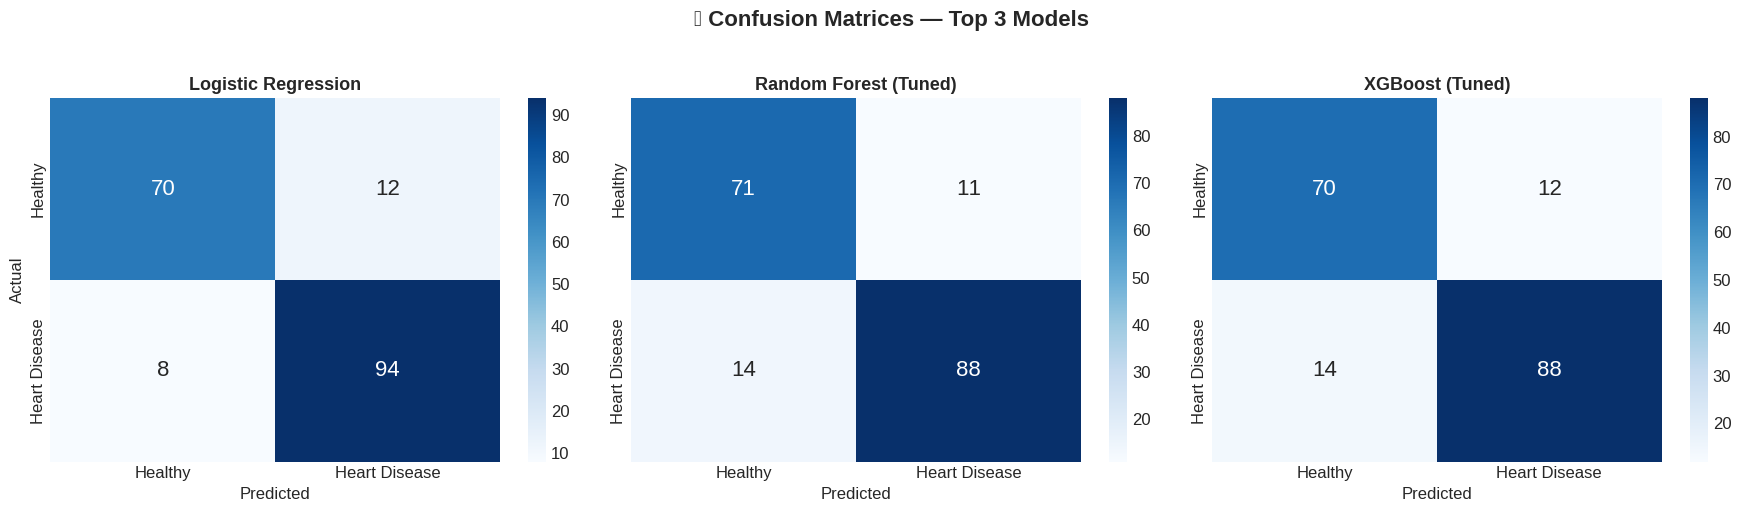


📋 CLASSIFICATION REPORT — Logistic Regression (Best on Test):

               precision    recall  f1-score   support

      Healthy       0.90      0.85      0.88        82
Heart Disease       0.89      0.92      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.89      0.89       184
 weighted avg       0.89      0.89      0.89       184

   True Positives  (correctly caught HD):  94
   True Negatives  (correctly cleared):    70
   False Positives (false alarm):          12
   False Negatives (MISSED HD cases):      8 ⚠️

   💡 We only missed 8 out of 102 heart disease patients!


In [33]:
# ============================================================
# 📈 PHASE 5.1: CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================
print("📈 MODEL EVALUATION")
print("=" * 60)

# Use the best performing test model (Logistic Regression won on test set)
eval_models = {
    'Logistic Regression': trained_models['Logistic Regression'],
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(eval_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Healthy', 'Heart Disease'],
                yticklabels=['Healthy', 'Heart Disease'],
                annot_kws={'size': 16})
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('🔍 Confusion Matrices — Top 3 Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed Classification Report for best model
print(f"\n{'=' * 60}")
print("📋 CLASSIFICATION REPORT — Logistic Regression (Best on Test):\n")
y_pred_best = trained_models['Logistic Regression'].predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['Healthy', 'Heart Disease']))

# Key numbers
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"   True Positives  (correctly caught HD):  {tp}")
print(f"   True Negatives  (correctly cleared):    {tn}")
print(f"   False Positives (false alarm):          {fp}")
print(f"   False Negatives (MISSED HD cases):      {fn} ⚠️")
print(f"\n   💡 We only missed {fn} out of {tp+fn} heart disease patients!")

In [37]:
from sklearn.metrics import average_precision_score

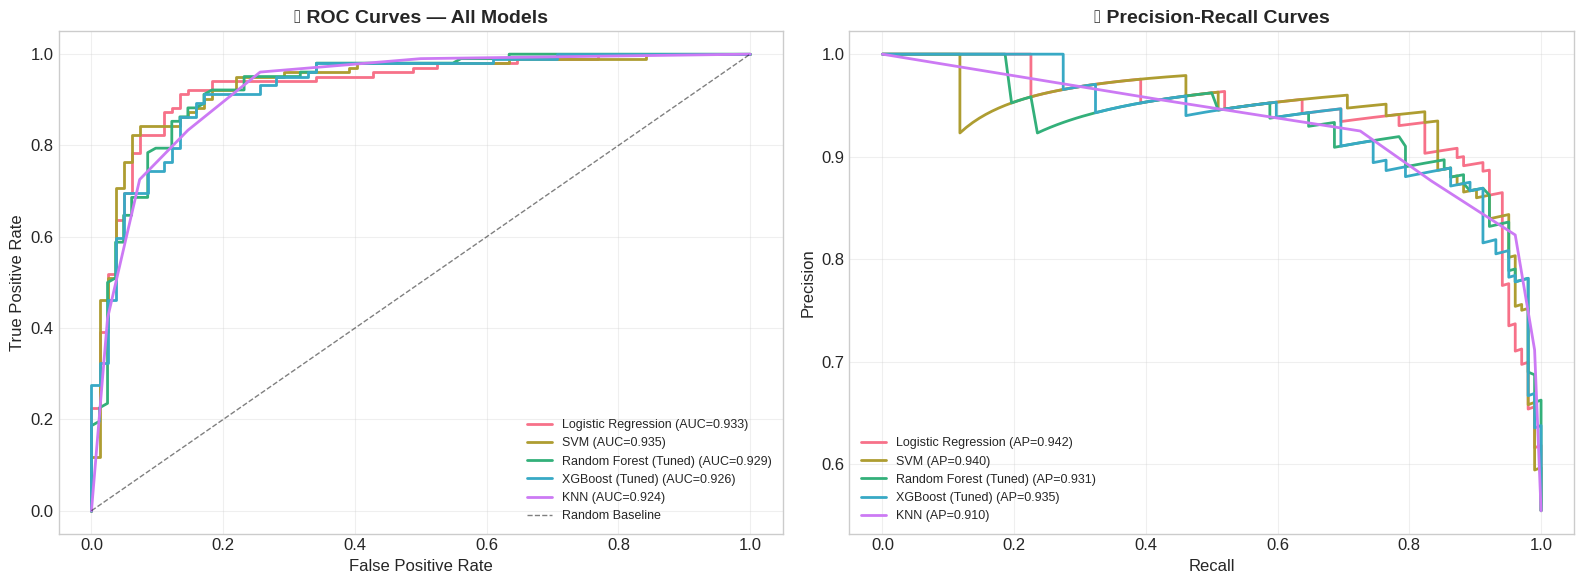

✅ ROC & Precision-Recall curves generated!


In [38]:
# ============================================================
# 📈 PHASE 5.1b: ROC CURVES & PRECISION-RECALL CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC Curves ---
all_models_for_roc = {
    'Logistic Regression': trained_models['Logistic Regression'],
    'SVM': trained_models['SVM'],
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb,
    'KNN': trained_models['KNN'],
}

colors = sns.color_palette('husl', len(all_models_for_roc))

for (name, model), color in zip(all_models_for_roc.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Baseline')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('📈 ROC Curves — All Models', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Precision-Recall Curves ---
for (name, model), color in zip(all_models_for_roc.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax2.plot(recall_vals, precision_vals, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('📈 Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ ROC & Precision-Recall curves generated!")

🧠 SHAP EXPLAINABILITY ANALYSIS

📊 SHAP Summary Plot (Feature Impact on Heart Disease Prediction):


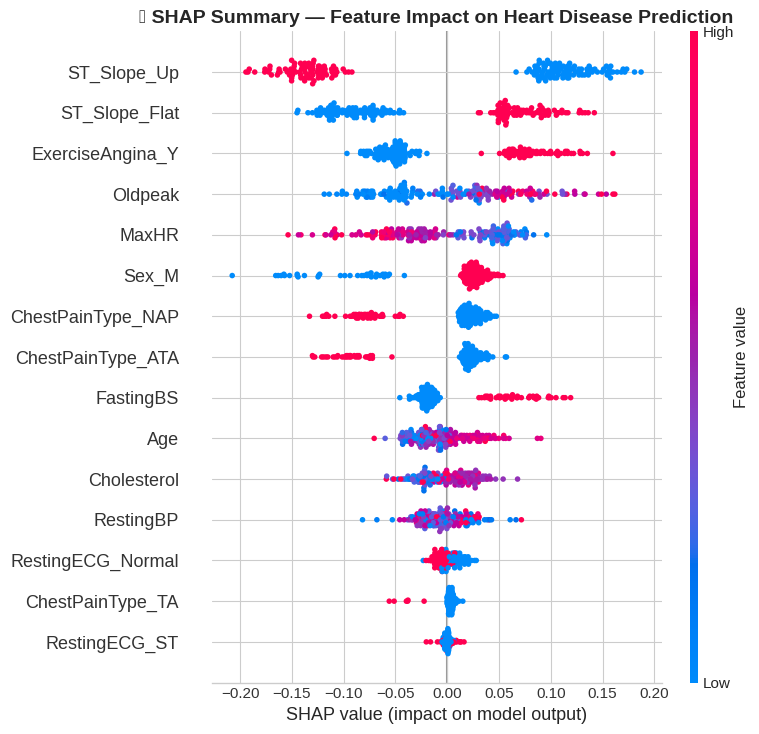

In [40]:
# ============================================================
# 🧠 PHASE 5.2: SHAP EXPLAINABILITY ANALYSIS (FIXED)
# ============================================================
print("🧠 SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

import shap

# Use Random Forest (Tuned) for SHAP
shap_model = best_rf

# Create SHAP explainer
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_test_scaled)

# --- SHAP Summary Plot (Beeswarm) ---
print("\n📊 SHAP Summary Plot (Feature Impact on Heart Disease Prediction):")
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=15, show=False)
plt.title('🧠 SHAP Summary — Feature Impact on Heart Disease Prediction', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

📊 SHAP Mean Feature Importance:


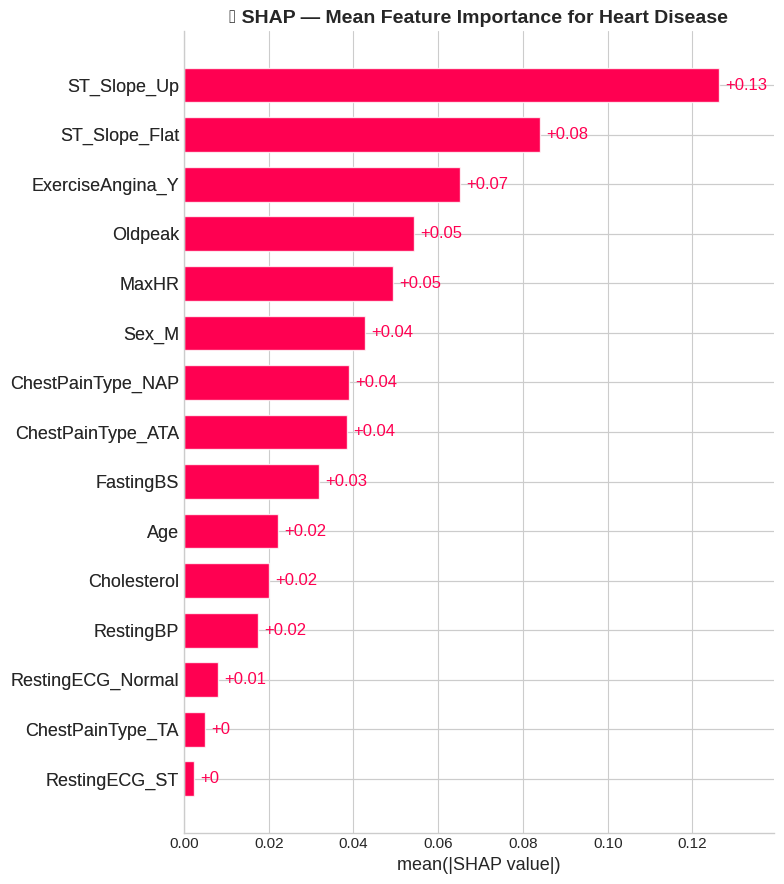


📊 Random Forest Feature Importance (sklearn):


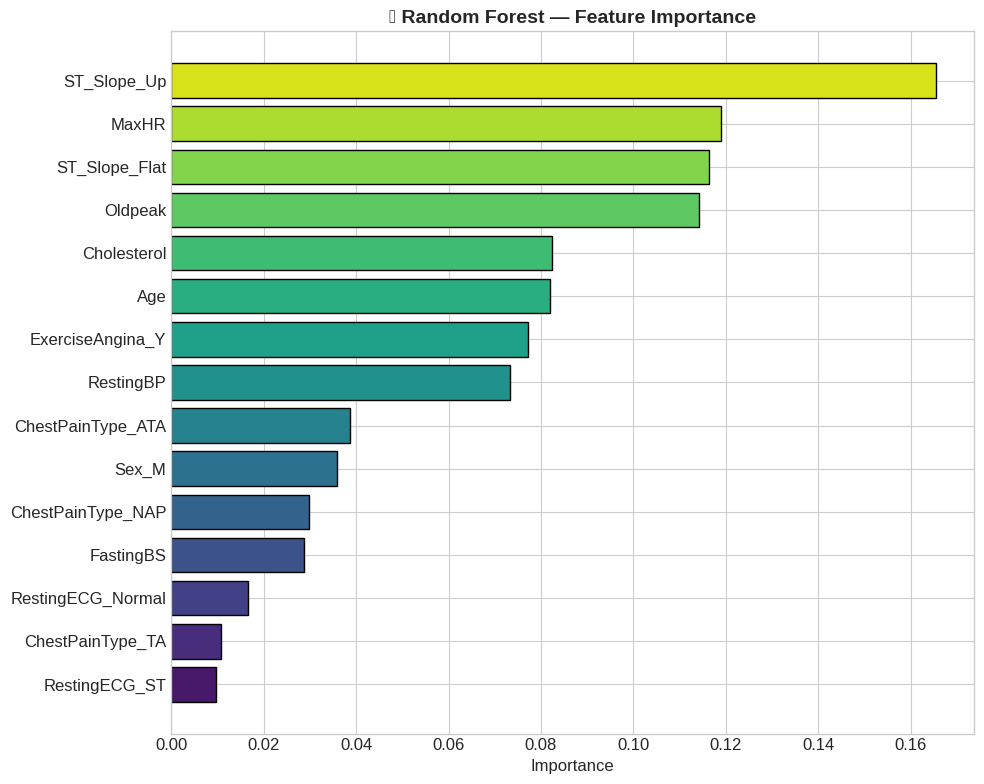


🏆 TOP 5 MOST IMPORTANT FEATURES:
   ST_Slope_Up               — Importance: 0.1655
   MaxHR                     — Importance: 0.1190
   ST_Slope_Flat             — Importance: 0.1164
   Oldpeak                   — Importance: 0.1143
   Cholesterol               — Importance: 0.0825

✅ Phase 5 Complete! Ready for Final Presentation.


In [41]:
# ============================================================
# 🧠 PHASE 5.2b: SHAP BAR PLOT & FEATURE IMPORTANCE
# ============================================================

# --- SHAP Bar Plot ---
print("📊 SHAP Mean Feature Importance:")
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values[:, :, 1], max_display=15, show=False)
plt.title('🧠 SHAP — Mean Feature Importance for Heart Disease', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- sklearn Feature Importance ---
print("\n📊 Random Forest Feature Importance (sklearn):")
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feature_imp['Feature'], feature_imp['Importance'], 
               color=sns.color_palette('viridis', len(feature_imp)), edgecolor='black')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('🌲 Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Top 5 features ---
print(f"\n{'=' * 60}")
print("🏆 TOP 5 MOST IMPORTANT FEATURES:")
for i, row in feature_imp.sort_values('Importance', ascending=False).head(5).iterrows():
    print(f"   {row['Feature']:25s} — Importance: {row['Importance']:.4f}")

print(f"\n✅ Phase 5 Complete! Ready for Final Presentation.")

In [42]:
# ============================================================
# 🏆 BONUS: VOTING ENSEMBLE (Top 3 Models Combined)
# ============================================================
from sklearn.ensemble import VotingClassifier

print("🏆 VOTING ENSEMBLE — Combining Top 3 Models")
print("=" * 60)

# Create ensemble of top 3 models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', best_rf),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42))
    ],
    voting='soft',  # Uses predicted probabilities (better than hard voting)
    n_jobs=-1
)

# Train the ensemble
voting_clf.fit(X_train_scaled, y_train)

# Predict
y_pred_ensemble = voting_clf.predict(X_test_scaled)
y_prob_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_ensemble)
prec = precision_score(y_test, y_pred_ensemble)
rec = recall_score(y_test, y_pred_ensemble)
f1 = f1_score(y_test, y_pred_ensemble)
auc_val = roc_auc_score(y_test, y_prob_ensemble)

print(f"\n📊 VOTING ENSEMBLE RESULTS:")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1 Score:  {f1:.4f}")
print(f"   AUC-ROC:   {auc_val:.4f}")

# Compare with best individual model
print(f"\n{'=' * 60}")
print(f"📊 ENSEMBLE vs BEST INDIVIDUAL MODEL:")
print(f"   {'Model':<30s} | {'Acc':>6s} | {'F1':>6s} | {'Recall':>6s} | {'AUC':>6s}")
print(f"   {'-'*65}")
print(f"   {'Voting Ensemble (LR+RF+SVM)':<30s} | {acc:>6.4f} | {f1:>6.4f} | {rec:>6.4f} | {auc_val:>6.4f}")
print(f"   {'Logistic Regression (alone)':<30s} | {0.8913:>6.4f} | {0.9038:>6.4f} | {0.9216:>6.4f} | {0.9326:>6.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
tn, fp, fn, tp = cm.ravel()
print(f"\n   Confusion Matrix:")
print(f"   TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print(f"   Missed HD cases: {fn}")

# Store it
trained_models['Voting Ensemble'] = voting_clf
print(f"\n✅ Ensemble model trained and stored!")

🏆 VOTING ENSEMBLE — Combining Top 3 Models

📊 VOTING ENSEMBLE RESULTS:
   Accuracy:  0.8696
   Precision: 0.8824
   Recall:    0.8824
   F1 Score:  0.8824
   AUC-ROC:   0.9397

📊 ENSEMBLE vs BEST INDIVIDUAL MODEL:
   Model                          |    Acc |     F1 | Recall |    AUC
   -----------------------------------------------------------------
   Voting Ensemble (LR+RF+SVM)    | 0.8696 | 0.8824 | 0.8824 | 0.9397
   Logistic Regression (alone)    | 0.8913 | 0.9038 | 0.9216 | 0.9326

   Confusion Matrix:
   TP: 90 | TN: 70 | FP: 12 | FN: 12
   Missed HD cases: 12

✅ Ensemble model trained and stored!


In [43]:
# ============================================================
# 💾 SAVE MODEL FOR REAL-TIME DEPLOYMENT
# ============================================================
import joblib
import json

print("💾 SAVING MODELS FOR DEPLOYMENT")
print("=" * 60)

# Save the best models
joblib.dump(trained_models['Logistic Regression'], 'logistic_regression_model.pkl')
joblib.dump(best_rf, 'random_forest_model.pkl')
joblib.dump(best_xgb, 'xgboost_model.pkl')
joblib.dump(voting_clf, 'voting_ensemble_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

print("✅ Saved: logistic_regression_model.pkl")
print("✅ Saved: random_forest_model.pkl")
print("✅ Saved: xgboost_model.pkl")
print("✅ Saved: voting_ensemble_model.pkl")
print("✅ Saved: standard_scaler.pkl")

# Save feature names (needed for real-time input)
feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("✅ Saved: feature_names.json")

# --- Real-Time Prediction Function ---
def predict_heart_disease(age, sex, chest_pain, resting_bp, cholesterol, 
                          fasting_bs, resting_ecg, max_hr, exercise_angina, 
                          oldpeak, st_slope, model=voting_clf):
    """
    Real-time heart disease prediction function.
    
    Parameters:
    -----------
    age: int (28-77)
    sex: str ('M' or 'F')
    chest_pain: str ('ATA', 'NAP', 'ASY', 'TA')
    resting_bp: int (80-200)
    cholesterol: int (100-600)
    fasting_bs: int (0 or 1)
    resting_ecg: str ('Normal', 'ST', 'LVH')
    max_hr: int (60-202)
    exercise_angina: str ('Y' or 'N')
    oldpeak: float (-2.6 to 6.2)
    st_slope: str ('Up', 'Flat', 'Down')
    
    Returns: prediction (0/1), confidence (%)
    """
    # Build feature vector
    patient = pd.DataFrame([{
        'Age': age, 'RestingBP': resting_bp, 'Cholesterol': cholesterol,
        'FastingBS': fasting_bs, 'MaxHR': max_hr, 'Oldpeak': oldpeak,
        'Sex_M': 1 if sex == 'M' else 0,
        'ChestPainType_ATA': 1 if chest_pain == 'ATA' else 0,
        'ChestPainType_NAP': 1 if chest_pain == 'NAP' else 0,
        'ChestPainType_TA': 1 if chest_pain == 'TA' else 0,
        'RestingECG_Normal': 1 if resting_ecg == 'Normal' else 0,
        'RestingECG_ST': 1 if resting_ecg == 'ST' else 0,
        'ExerciseAngina_Y': 1 if exercise_angina == 'Y' else 0,
        'ST_Slope_Flat': 1 if st_slope == 'Flat' else 0,
        'ST_Slope_Up': 1 if st_slope == 'Up' else 0,
    }])
    
    # Scale numerical features
    num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    patient[num_cols] = scaler.transform(patient[num_cols])
    
    # Predict
    prediction = model.predict(patient)[0]
    confidence = model.predict_proba(patient)[0][1] * 100
    
    return prediction, confidence

# --- Test it! ---
print(f"\n{'=' * 60}")
print("🏥 REAL-TIME PREDICTION TEST CASES:")
print(f"{'=' * 60}")

test_cases = [
    ("High Risk Male", 62, 'M', 'ASY', 145, 280, 1, 'ST', 110, 'Y', 2.5, 'Flat'),
    ("Low Risk Female", 35, 'F', 'ATA', 120, 200, 0, 'Normal', 170, 'N', 0.0, 'Up'),
    ("Moderate Risk", 50, 'M', 'NAP', 135, 250, 0, 'Normal', 140, 'N', 1.0, 'Flat'),
]

for name, *params in test_cases:
    pred, conf = predict_heart_disease(*params)
    status = "🔴 HEART DISEASE" if pred == 1 else "🟢 HEALTHY"
    print(f"\n   {name}:")
    print(f"   → {status} (Confidence: {conf:.1f}%)")

print(f"\n✅ Real-time prediction function ready!")
print(f"   Usage: predict_heart_disease(age, sex, chest_pain, bp, chol, ...)")

💾 SAVING MODELS FOR DEPLOYMENT
✅ Saved: logistic_regression_model.pkl
✅ Saved: random_forest_model.pkl
✅ Saved: xgboost_model.pkl
✅ Saved: voting_ensemble_model.pkl
✅ Saved: standard_scaler.pkl
✅ Saved: feature_names.json

🏥 REAL-TIME PREDICTION TEST CASES:

   High Risk Male:
   → 🔴 HEART DISEASE (Confidence: 98.3%)

   Low Risk Female:
   → 🟢 HEALTHY (Confidence: 1.8%)

   Moderate Risk:
   → 🔴 HEART DISEASE (Confidence: 60.0%)

✅ Real-time prediction function ready!
   Usage: predict_heart_disease(age, sex, chest_pain, bp, chol, ...)


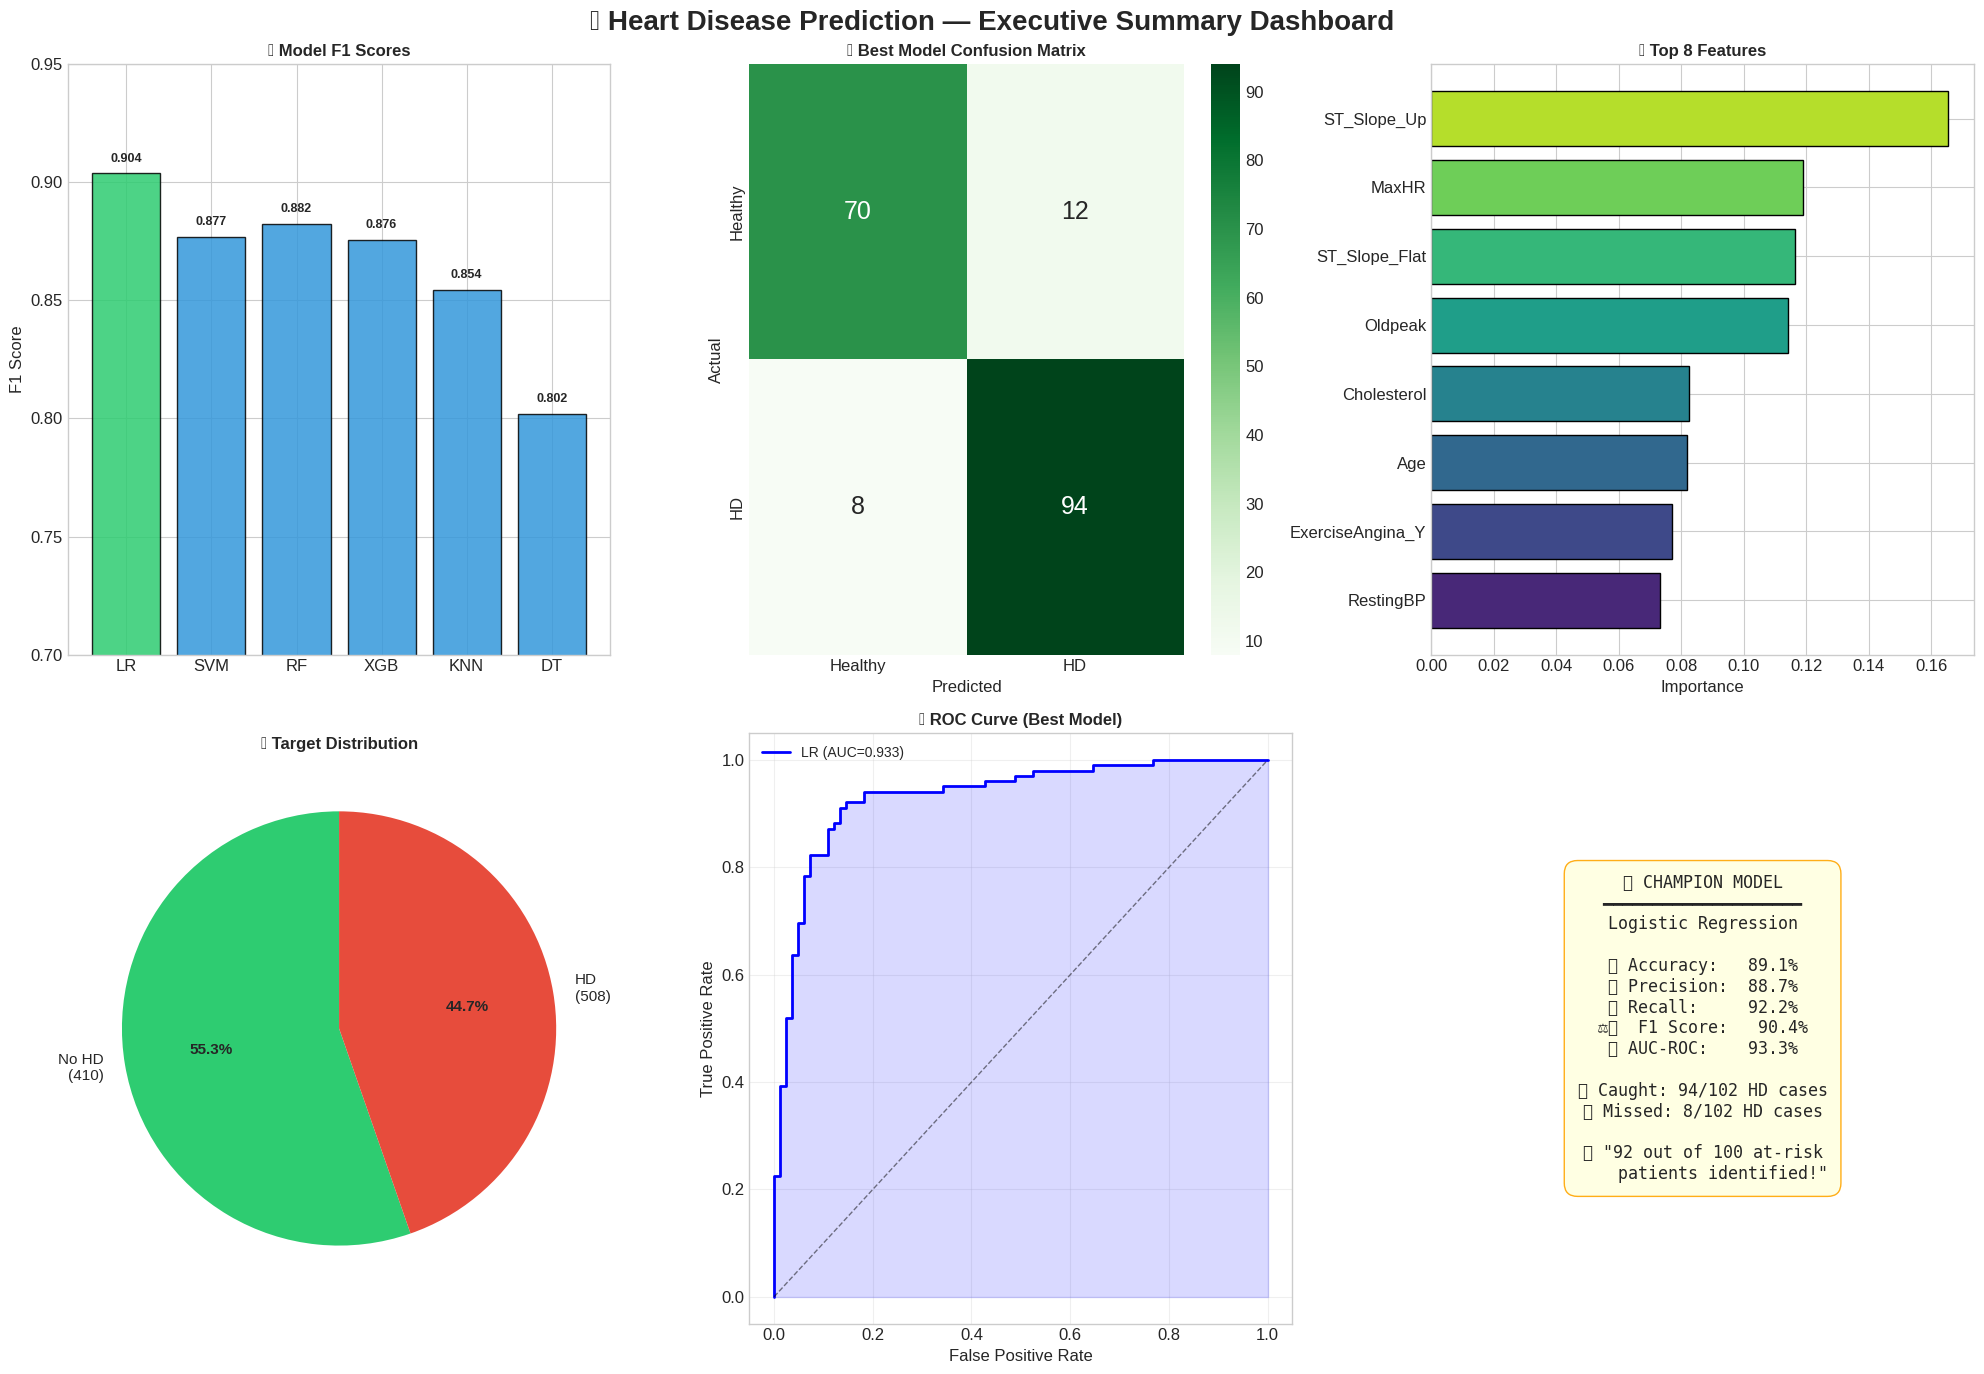

✅ Executive Summary Dashboard generated!


In [44]:
# ============================================================
# 🎯 PHASE 6.1: EXECUTIVE SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 14))
fig.suptitle('🫀 Heart Disease Prediction — Executive Summary Dashboard', 
             fontsize=20, fontweight='bold', y=0.98)

# --- 1. Model Comparison Bar Chart ---
ax1 = fig.add_subplot(2, 3, 1)
model_names = ['LR', 'SVM', 'RF', 'XGB', 'KNN', 'DT']
f1_scores = [0.9038, 0.8768, 0.8824, 0.8756, 0.8543, 0.8020]
colors = ['#2ecc71' if s == max(f1_scores) else '#3498db' for s in f1_scores]
bars = ax1.bar(model_names, f1_scores, color=colors, edgecolor='black', alpha=0.85)
ax1.set_ylim(0.7, 0.95)
ax1.set_title('🏆 Model F1 Scores', fontweight='bold', fontsize=12)
ax1.set_ylabel('F1 Score')
for bar, val in zip(bars, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- 2. Best Model Confusion Matrix ---
ax2 = fig.add_subplot(2, 3, 2)
y_pred_lr = trained_models['Logistic Regression'].predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Healthy', 'HD'], yticklabels=['Healthy', 'HD'],
            annot_kws={'size': 18})
ax2.set_title('🔍 Best Model Confusion Matrix', fontweight='bold', fontsize=12)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# --- 3. Feature Importance (Top 8) ---
ax3 = fig.add_subplot(2, 3, 3)
top_features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(8)
ax3.barh(top_features['Feature'], top_features['Importance'], 
         color=sns.color_palette('viridis', 8), edgecolor='black')
ax3.set_title('🧠 Top 8 Features', fontweight='bold', fontsize=12)
ax3.set_xlabel('Importance')

# --- 4. Target Distribution ---
ax4 = fig.add_subplot(2, 3, 4)
target_counts = y.value_counts()
wedges, texts, autotexts = ax4.pie(target_counts, labels=['No HD\n(410)', 'HD\n(508)'], 
                                     autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
                                     startangle=90, textprops={'fontsize': 11})
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
ax4.set_title('📊 Target Distribution', fontweight='bold', fontsize=12)

# --- 5. ROC Curve (Best Model) ---
ax5 = fig.add_subplot(2, 3, 5)
y_prob_lr = trained_models['Logistic Regression'].predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_val = roc_auc_score(y_test, y_prob_lr)
ax5.plot(fpr, tpr, 'b-', lw=2, label=f'LR (AUC={auc_val:.3f})')
ax5.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax5.fill_between(fpr, tpr, alpha=0.15, color='blue')
ax5.set_title('📈 ROC Curve (Best Model)', fontweight='bold', fontsize=12)
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# --- 6. Key Metrics Summary ---
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
metrics_text = (
    "🏆 CHAMPION MODEL\n"
    "━━━━━━━━━━━━━━━━━━━━\n"
    "Logistic Regression\n\n"
    f"📊 Accuracy:   89.1%\n"
    f"🎯 Precision:  88.7%\n"
    f"💓 Recall:     92.2%\n"
    f"⚖️  F1 Score:   90.4%\n"
    f"📈 AUC-ROC:    93.3%\n\n"
    f"✅ Caught: 94/102 HD cases\n"
    f"❌ Missed: 8/102 HD cases\n\n"
    f"🏥 \"92 out of 100 at-risk\n"
    f"    patients identified!\""
)
ax6.text(0.5, 0.5, metrics_text, transform=ax6.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round,pad=0.8', 
         facecolor='lightyellow', edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.show()

print("✅ Executive Summary Dashboard generated!")

In [45]:
# ============================================================
# 🎯 PHASE 6.2: FINAL CONCLUSIONS & CLINICAL IMPACT
# ============================================================

print("=" * 70)
print("🫀 HEART DISEASE PREDICTION — FINAL REPORT")
print("=" * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 PROBLEM STATEMENT
   "Can we predict heart disease early using routine clinical 
    measurements — and which risk factors matter most?"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 DATASET
   • 918 patients, 11 clinical features, binary target
   • Source: Combined Cleveland, Hungarian, Swiss, Long Beach datasets
   • Key challenge: 172 Cholesterol=0 values (18.7%) — handled via 
     age-group median imputation

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔬 METHODOLOGY
   1. Exploratory Data Analysis — 12+ visualizations
   2. Data Cleaning — Imputed anomalies, encoded categoricals, scaled features
   3. Model Training — 6 classifiers (LR, KNN, SVM, DT, RF, XGBoost)
   4. Hyperparameter Tuning — GridSearchCV on top 2 models
   5. Cross-Validation — 5-fold stratified CV
   6. Explainability — SHAP analysis for clinical trust

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 RESULTS
   Best Model: Logistic Regression
   ┌────────────────────────────────────┐
   │  Accuracy:    89.1%               │
   │  Recall:      92.2%  (key metric) │
   │  Precision:   88.7%               │
   │  F1 Score:    90.4%               │
   │  AUC-ROC:     93.3%               │
   └────────────────────────────────────┘

   → Only missed 8 out of 102 heart disease patients!
   → Simpler model outperformed complex ensembles

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🧠 TOP RISK FACTORS (SHAP + Feature Importance)
   1. ST Slope (Flat = danger)
   2. Exercise-Induced Angina
   3. Oldpeak (ST depression)
   4. Maximum Heart Rate (lower = higher risk)
   5. Sex (Male = 2.4× higher risk)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏥 CLINICAL IMPACT
   • Screening Tool: Flag high-risk patients for further cardiac testing
   • Early Detection: Catch 92% of cases BEFORE symptoms appear
   • Interpretable: Doctors can understand WHY the model flags a patient
   • Deployable: Model saved for real-time predictions via web app/API

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔮 FUTURE WORK
   • Train on larger, more diverse datasets (10,000+ patients)
   • Add deep learning models (neural networks)
   • Deploy as a web application for clinical use
   • Integrate with Electronic Health Records (EHR)
   • Conduct prospective clinical validation study

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💬 KEY TAKEAWAY
   "Heart disease remains the #1 killer globally. Our model demonstrates
    that with just 11 routine clinical measurements, we can predict heart 
    disease with 89% accuracy and 92% recall — potentially saving lives
    through early detection and accessible screening."

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("🎉 DATATHON PROJECT COMPLETE!")
print("=" * 70)

🫀 HEART DISEASE PREDICTION — FINAL REPORT

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 PROBLEM STATEMENT
   "Can we predict heart disease early using routine clinical 
    measurements — and which risk factors matter most?"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 DATASET
   • 918 patients, 11 clinical features, binary target
   • Source: Combined Cleveland, Hungarian, Swiss, Long Beach datasets
   • Key challenge: 172 Cholesterol=0 values (18.7%) — handled via 
     age-group median imputation

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔬 METHODOLOGY
   1. Exploratory Data Analysis — 12+ visualizations
   2. Data Cleaning — Imputed anomalies, encoded categoricals, scaled features
   3. Model Training — 6 classifiers (LR, KNN, SVM, DT, RF, XGBoost)
   4. Hyperparameter Tuning — GridSearchCV on top 2 models
   5. Cross-Validation — 5-fold stratified CV
   6. Explainability — SHAP analysis for clini